In [ ]:
# ============================================================
# BIRDS CubeSat - ML Based Autonomous Power Management
# Dataset: TSURU On-Orbit EPS Data (Jara et al., 2022)
# Targets: P_solar_total, Vbat, Tbatt
# Reference: DOI: 10.1016/j.dib.2022.108697
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVR, LinearSVR
from sklearn.model_selection import (TimeSeriesSplit, cross_val_score,
                                      GridSearchCV)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")


All libraries imported successfully


**Dataset:** TSURU CubeSat On-Orbit EPS Data (Jara et al., 2022)  
**Reference:** DOI: 10.1016/j.dib.2022.108697  
**Targets:** P_solar_total (µW), Vbat (V), Tbatt (℃)

Support Vector Regressor (SVR) is a kernel-based supervised learning
algorithm that finds a regression function by fitting data within an
**epsilon-insensitive tube** around the prediction hyperplane.

**Core idea:**
- Points INSIDE the ±ε tube → zero loss, ignored completely
- Points OUTSIDE the ±ε tube → become **Support Vectors**, penalized by C
- Final prediction depends ONLY on support vectors — not all training points

---

## Key Hyperparameters

| Parameter | Role | Effect |
|---|---|---|
| **C** | Regularization penalty | High C = fewer violations, risk overfitting |
| **ε (epsilon)** | Tube half-width | Large ε = wider tube, fewer support vectors |
| **kernel** | Feature mapping function | Controls linearity vs non-linearity |
| **gamma** | RBF kernel width | High γ = local model, Low γ = global model |

---

## Kernels Compared

| Kernel | Formula | Use Case |
|---|---|---|
| **linear** | x · x' | Linearly separable data |
| **rbf** | exp(-γ\|\|x-x'\|\|²) | Most common, handles non-linearity |
| **poly** | (γx · x' + r)^d | Polynomial relationships |
| **sigmoid** | tanh(γx · x' + r) | Neural-network-like boundary |

---

## Why StandardScaler is REQUIRED

SVR computes distances between data points via the kernel function.
Features on different scales (e.g., Voltage in mV vs Temperature in °C)
will completely dominate the distance calculation. Unlike tree-based
models (RF, DT), SVR breaks entirely without scaling.

**Rule:** Scaler fitted on training data ONLY, then applied to test.

---

## Computational Note

SVR training complexity scales as **O(n² to n³)** with the number of
training samples. On 19,383 samples, a single fit would take hours.

| Step | Samples Used | Reason |
|---|---|---|
| C sweep | 5,000 subset | Feasibility |
| Epsilon sweep | 5,000 subset | Feasibility |
| Kernel comparison | 5,000 subset | Feasibility |
| Gamma sweep | 5,000 subset | Feasibility |
| RandomizedSearchCV | 5,000 subset | 50 iter × 5 folds |
| **Final model** | **19,383 full** | **Best accuracy** |

**Why RandomizedSearchCV instead of GridSearchCV:**
GridSearchCV with a full parameter grid would take days on SVR.
A reduced grid risks missing optimal parameters. RandomizedSearchCV
samples 50 random combinations from a **large continuous search space**
(C from 0.1–1000, ε from 0.001–5.0 via log-uniform distributions),
giving better parameter coverage in the same computation time.

Reference: Bergstra & Bengio (2012), *Random Search for
Hyper-Parameter Optimization*, JMLR.

---

In [ ]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Sabarivarhman G M\Downloads\ML_proj\TSURU_cleaned.csv")

df.head()

print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

# ---- Leakage-free feature sets (established in Notebook 03) ----
FEATURES_SOLAR = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'sin_orbit', 'cos_orbit'
]

FEATURES_VBAT = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'sin_orbit', 'cos_orbit'
]

FEATURES_TBATT = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)',
    'Vbat (V)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'sin_orbit', 'cos_orbit'
]

TARGET_PRIMARY   = 'P_solar_total (µW)'
TARGET_SECONDARY = 'Vbat (V)'
TARGET_TERTIARY  = 'Tbatt (℃)'

# ---- TimeSeriesSplit ----
tscv      = TimeSeriesSplit(n_splits=5)
splits    = list(tscv.split(df))
train_idx = splits[-1][0]
test_idx  = splits[-1][1]

datasets = {
    'Primary'  : (df[FEATURES_SOLAR], df[TARGET_PRIMARY],   FEATURES_SOLAR),
    'Secondary': (df[FEATURES_VBAT],  df[TARGET_SECONDARY], FEATURES_VBAT),
    'Tertiary' : (df[FEATURES_TBATT], df[TARGET_TERTIARY],  FEATURES_TBATT)
}

# ---- Subset for parameter sweeps (SVR computational constraint) ----
np.random.seed(42)
SUBSET_SIZE = 5000
subset_mask = np.random.choice(train_idx, size=SUBSET_SIZE, replace=False)
subset_mask = np.sort(subset_mask)

print(f"\nTrain size      : {len(train_idx)}")
print(f"Test size       : {len(test_idx)}")
print(f"Tuning subset   : {SUBSET_SIZE} (for SVR parameter sweeps)")
print(f"\nFeature sets (leakage-free):")
print(f"  P_solar_total : {len(FEATURES_SOLAR)} features (currents removed)")
print(f"  Vbat          : {len(FEATURES_VBAT)} features (Vbat removed from inputs)")
print(f"  Tbatt         : {len(FEATURES_TBATT)} features (DeltaT removed)")
print(f"\nIMPORTANT: SVR requires StandardScaler")
print(f"  Scaler fitted on training data only — applied to train and test")

Dataset loaded successfully!
Shape: 23259 rows x 35 columns

Train size      : 19383
Test size       : 3876
Tuning subset   : 5000 (for SVR parameter sweeps)

Feature sets (leakage-free):
  P_solar_total : 12 features (currents removed)
  Vbat          : 12 features (Vbat removed from inputs)
  Tbatt         : 13 features (DeltaT removed)

IMPORTANT: SVR requires StandardScaler
  Scaler fitted on training data only — applied to train and test


In [ ]:
# ============================================================
# SECTION 2: BASE MODEL — DEFAULT SVR PARAMETERS
# kernel='rbf', C=1.0, epsilon=0.1, gamma='scale'
# StandardScaler applied before fitting
# ============================================================

results_before = {}
scalers_before = {}

print("=" * 65)
print("BASE MODEL — SVR (default parameters)")
print("  kernel  = rbf")
print("  C       = 1.0  (regularization — penalty for margin violations)")
print("  epsilon = 0.1  (tube half-width — insensitive zone)")
print("  gamma   = scale (1 / (n_features * X.var()))")
print("  NOTE: StandardScaler applied before SVR")
print("=" * 65)

for name, (X, y, feats) in datasets.items():
    X_train_full = X.iloc[train_idx]
    X_test       = X.iloc[test_idx]
    y_train_full = y.iloc[train_idx]
    y_test       = y.iloc[test_idx]

    # Scale
    scaler  = StandardScaler()
    Xtr_sc  = scaler.fit_transform(X_train_full)
    Xte_sc  = scaler.transform(X_test)

    # Fit base model on FULL training set
    model = SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale')
    model.fit(Xtr_sc, y_train_full)
    y_pred = model.predict(Xte_sc)

    r2       = r2_score(y_test, y_pred)
    rmse     = np.sqrt(mean_squared_error(y_test, y_pred))
    mae      = mean_absolute_error(y_test, y_pred)
    mse      = mean_squared_error(y_test, y_pred)
    train_r2 = r2_score(y_train_full, model.predict(Xtr_sc))
    n_sv     = model.n_support_[0]

    results_before[name] = {
        'R2': r2, 'RMSE': rmse, 'MAE': mae, 'MSE': mse,
        'train_r2': train_r2, 'n_sv': n_sv,
        'y_pred': y_pred, 'y_test': y_test,
        'model': model, 'feats': feats, 'scaler': scaler
    }
    scalers_before[name] = scaler

    print(f"\nTarget          : {y.name}")
    print(f"Train R2        : {train_r2:.4f}")
    print(f"Test  R2        : {r2:.4f}")
    print(f"RMSE            : {rmse:.4f}")
    print(f"MAE             : {mae:.4f}")
    print(f"Support Vectors : {n_sv} / {len(train_idx)} "
          f"({100*n_sv/len(train_idx):.1f}% of training data)")

BASE MODEL — SVR (default parameters)
  kernel  = rbf
  C       = 1.0  (regularization — penalty for margin violations)
  epsilon = 0.1  (tube half-width — insensitive zone)
  gamma   = scale (1 / (n_features * X.var()))
  NOTE: StandardScaler applied before SVR

Target          : P_solar_total (µW)
Train R2        : -0.0139
Test  R2        : -0.0633
RMSE            : 913029.8934
MAE             : 715217.9588
Support Vectors : 19383 / 19383 (100.0% of training data)

Target          : Vbat (V)
Train R2        : 0.4993
Test  R2        : 0.4830
RMSE            : 0.0649
MAE             : 0.0566
Support Vectors : 55 / 19383 (0.3% of training data)

Target          : Tbatt (℃)
Train R2        : 0.7155
Test  R2        : -0.1136
RMSE            : 5.4714
MAE             : 3.3068
Support Vectors : 17586 / 19383 (90.7% of training data)


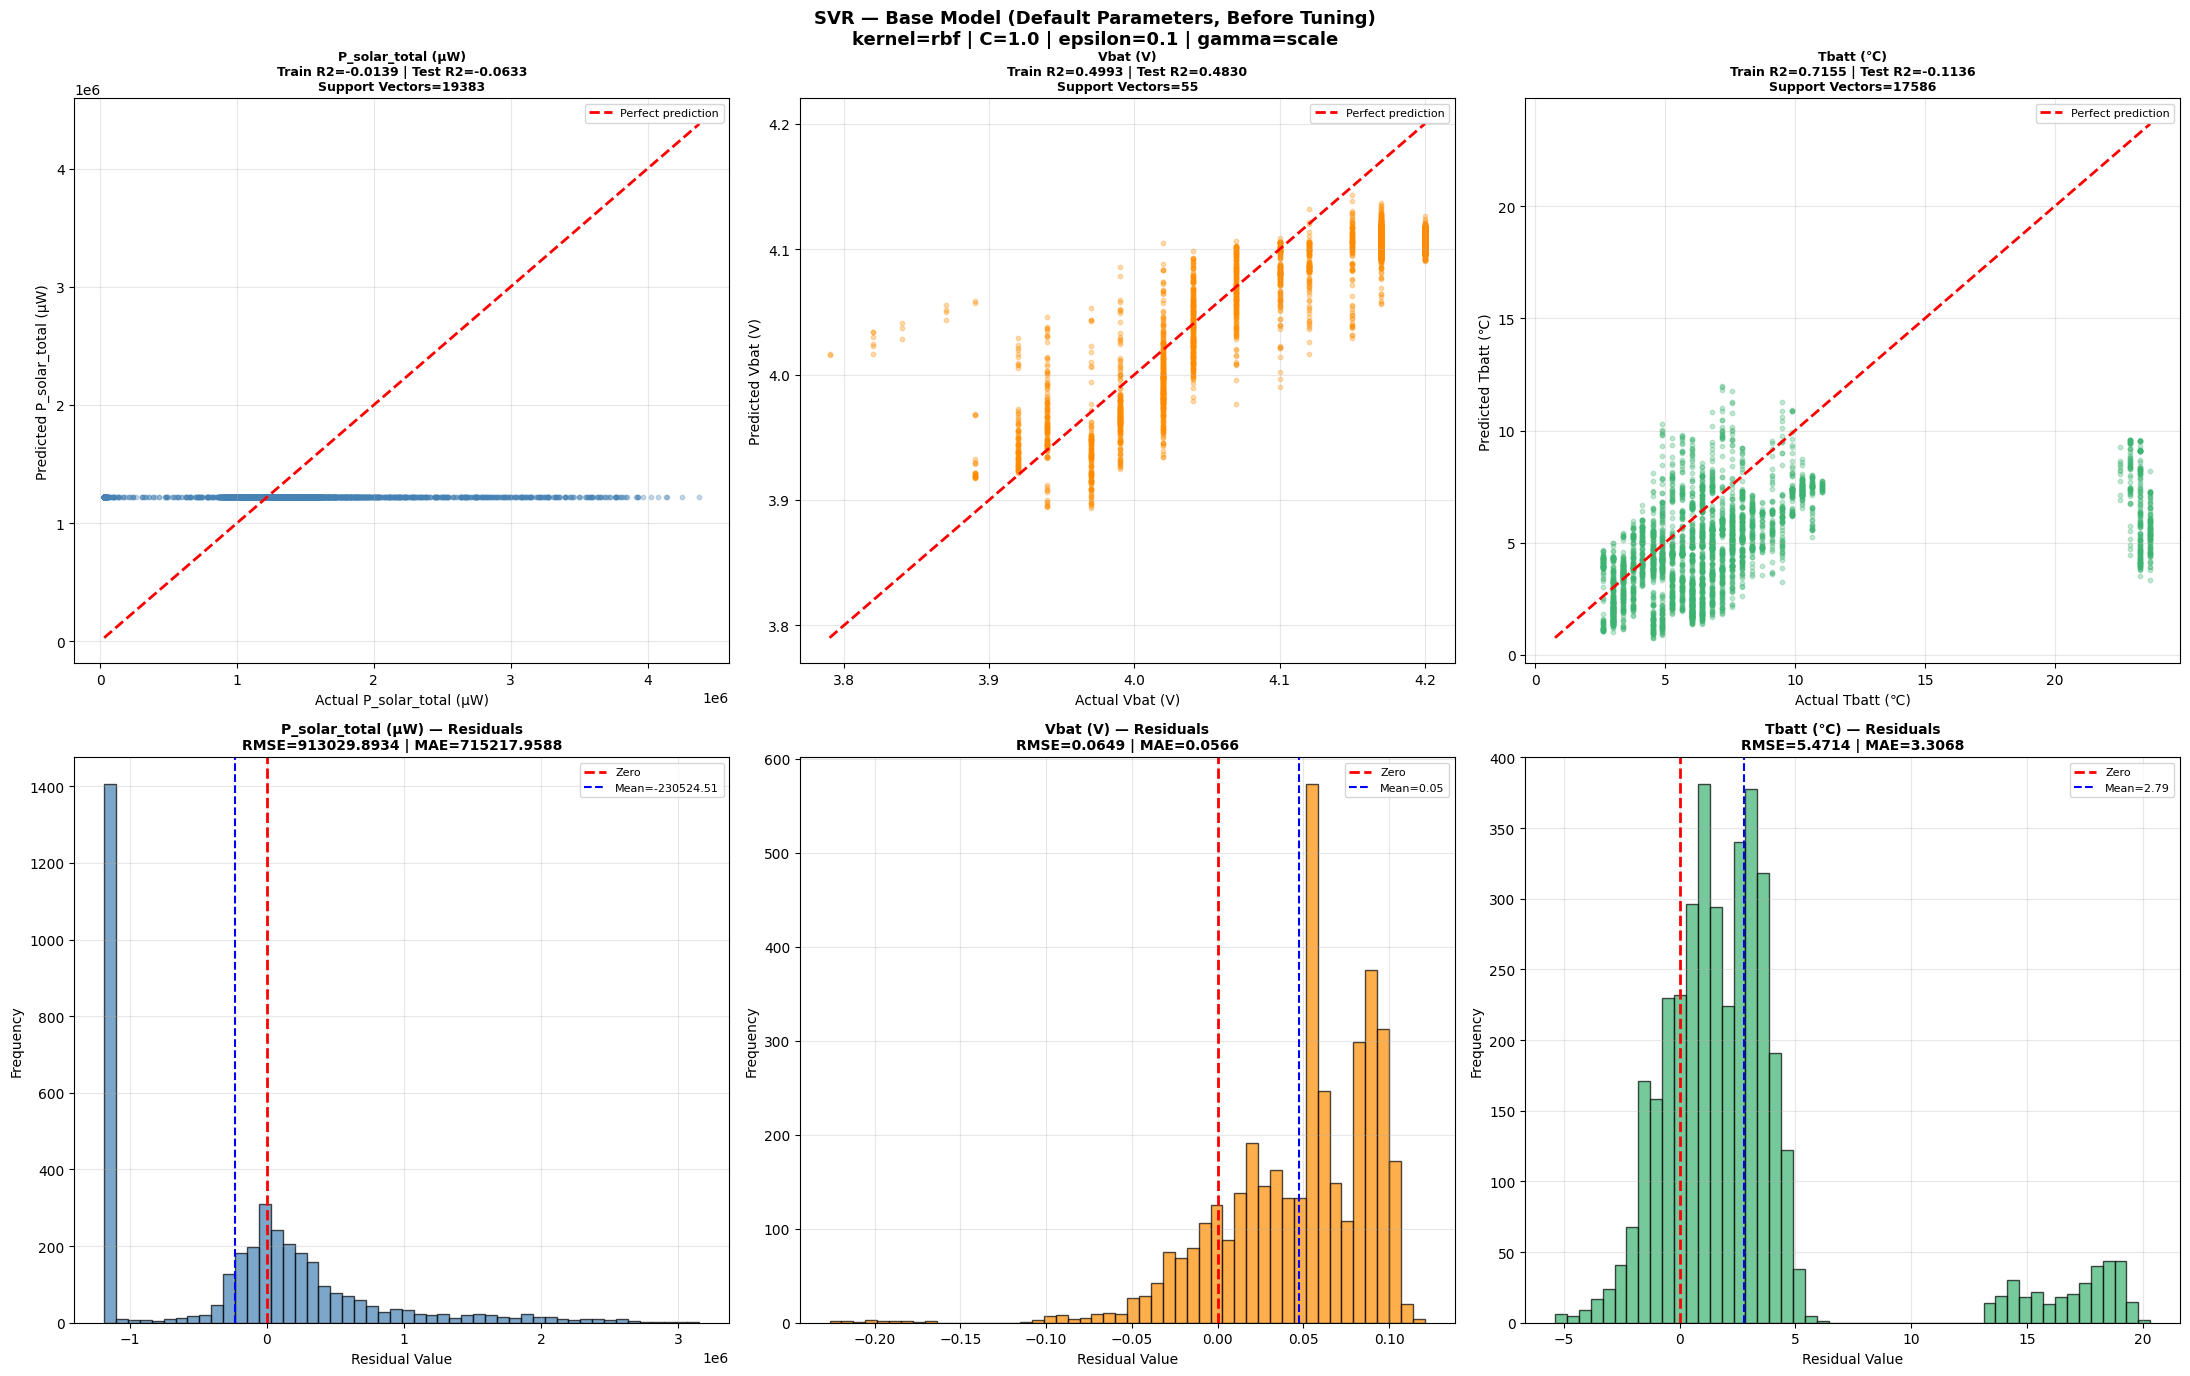

Base model plots saved.


In [ ]:
# ============================================================
# SECTION 3: BASE MODEL VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('SVR — Base Model (Default Parameters, Before Tuning)\n'
             'kernel=rbf | C=1.0 | epsilon=0.1 | gamma=scale',
             fontsize=13, fontweight='bold')

target_list = ['Primary', 'Secondary', 'Tertiary']
y_targets   = [TARGET_PRIMARY, TARGET_SECONDARY, TARGET_TERTIARY]
colors      = ['steelblue', 'darkorange', 'mediumseagreen']

for idx, (name, ytarget, clr) in enumerate(
        zip(target_list, y_targets, colors)):

    r      = results_before[name]
    y_pred = r['y_pred']
    y_test = r['y_test']
    resids = y_test.values - y_pred

    # Row 1: Actual vs Predicted
    ax = axes[0, idx]
    ax.scatter(y_test, y_pred, color=clr, alpha=0.3, s=10)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            color='red', linewidth=2, linestyle='--',
            label='Perfect prediction')
    ax.set_title(f'{ytarget}\nTrain R2={r["train_r2"]:.4f} | '
                 f'Test R2={r["R2"]:.4f}\n'
                 f'Support Vectors={r["n_sv"]}',
                 fontweight='bold', fontsize=9)
    ax.set_xlabel(f'Actual {ytarget}')
    ax.set_ylabel(f'Predicted {ytarget}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Row 2: Residual Distribution
    ax2 = axes[1, idx]
    ax2.hist(resids, bins=50, color=clr, edgecolor='black', alpha=0.7)
    ax2.axvline(x=0, color='red', linestyle='--',
                linewidth=2, label='Zero')
    ax2.axvline(x=resids.mean(), color='blue',
                linestyle='--', linewidth=1.5,
                label=f'Mean={resids.mean():.2f}')
    ax2.set_title(f'{ytarget} — Residuals\n'
                  f'RMSE={r["RMSE"]:.4f} | MAE={r["MAE"]:.4f}',
                  fontweight='bold', fontsize=10)
    ax2.set_xlabel('Residual Value')
    ax2.set_ylabel('Frequency')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_base_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("Base model plots saved.")

**Base Model Observations:**
- P_solar_total: Test R2 = -0.0633 — model predicts a flat constant (~1.2M µW) for all inputs. Default C=1.0 with epsilon=0.1 is completely unsuited to an output range of 500,000+ µW. All 19,383 training points became support vectors.
- Vbat: Test R2 = 0.4830 — moderate performance. Only 55 support vectors (0.3%) meaning the default epsilon=0.1 covers a large portion of Vbat's narrow 0.4V range.
- Tbatt: Test R2 = -0.1136 — worse than predicting the mean. 90.7% support vectors confirm the default tube is too tight for noisy thermal data.

**Key takeaway:** Default SVR parameters are highly sensitive to output scale. All three targets need target-specific tuning.

In [ ]:
# ============================================================
# SECTION 4: C PARAMETER TUNING
# C = regularization — penalty for exceeding epsilon tube
# Low C  = wide margin, more errors allowed (underfitting)
# High C = narrow margin, fewer errors tolerated (overfitting)
# Using n=5000 subset for computational feasibility
# ============================================================

C_range = [0.01, 0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000]

C_results = {name: {'train_r2': [], 'test_r2': [], 'n_sv': []}
             for name in datasets}

print("Testing C values:", C_range)
print("Using training subset of", SUBSET_SIZE, "samples")
print("=" * 70)

for name, (X, y, feats) in datasets.items():
    X_sub    = X.iloc[subset_mask]
    X_test   = X.iloc[test_idx]
    y_sub    = y.iloc[subset_mask]
    y_test   = y.iloc[test_idx]

    scaler   = StandardScaler()
    Xsub_sc  = scaler.fit_transform(X_sub)
    Xte_sc   = scaler.transform(X_test)

    print(f"\nTarget: {y.name}")
    print(f"{'C':<10} {'Train R2':>10} {'Test R2':>10} "
          f"{'N_SV':>8} {'RMSE':>15}")
    print("-" * 58)

    for c in C_range:
        model = SVR(kernel='rbf', C=c, epsilon=0.1, gamma='scale')
        model.fit(Xsub_sc, y_sub)

        train_r2 = r2_score(y_sub, model.predict(Xsub_sc))
        y_pred   = model.predict(Xte_sc)
        test_r2  = r2_score(y_test, y_pred)
        rmse     = np.sqrt(mean_squared_error(y_test, y_pred))
        n_sv     = model.n_support_[0]

        C_results[name]['train_r2'].append(train_r2)
        C_results[name]['test_r2'].append(test_r2)
        C_results[name]['n_sv'].append(n_sv)

        print(f"{c:<10} {train_r2:>10.4f} {test_r2:>10.4f} "
              f"{n_sv:>8} {rmse:>15.4f}")

    best_idx = np.argmax(C_results[name]['test_r2'])
    print(f"\n  Best C: {C_range[best_idx]} | "
          f"Best Test R2: {C_results[name]['test_r2'][best_idx]:.4f}")

Testing C values: [0.01, 0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000]
Using training subset of 5000 samples

Target: P_solar_total (µW)
C            Train R2    Test R2     N_SV            RMSE
----------------------------------------------------------
0.01          -0.0174    -0.0675     5000     914849.2710
0.1           -0.0173    -0.0674     5000     914790.7391
0.5           -0.0167    -0.0668     5000     914524.2835
1             -0.0161    -0.0660     5000     914196.7249
5             -0.0111    -0.0603     5000     911750.1654
10            -0.0048    -0.0530     5000     908584.2339
50             0.0439     0.0036     5000     883837.6519
100            0.1001     0.0693     5000     854220.5771
500            0.3862     0.4031     5000     684093.8503
1000           0.4687     0.4886     5000     633228.3466

  Best C: 1000 | Best Test R2: 0.4886

Target: Vbat (V)
C            Train R2    Test R2     N_SV            RMSE
---------------------------------------------------------

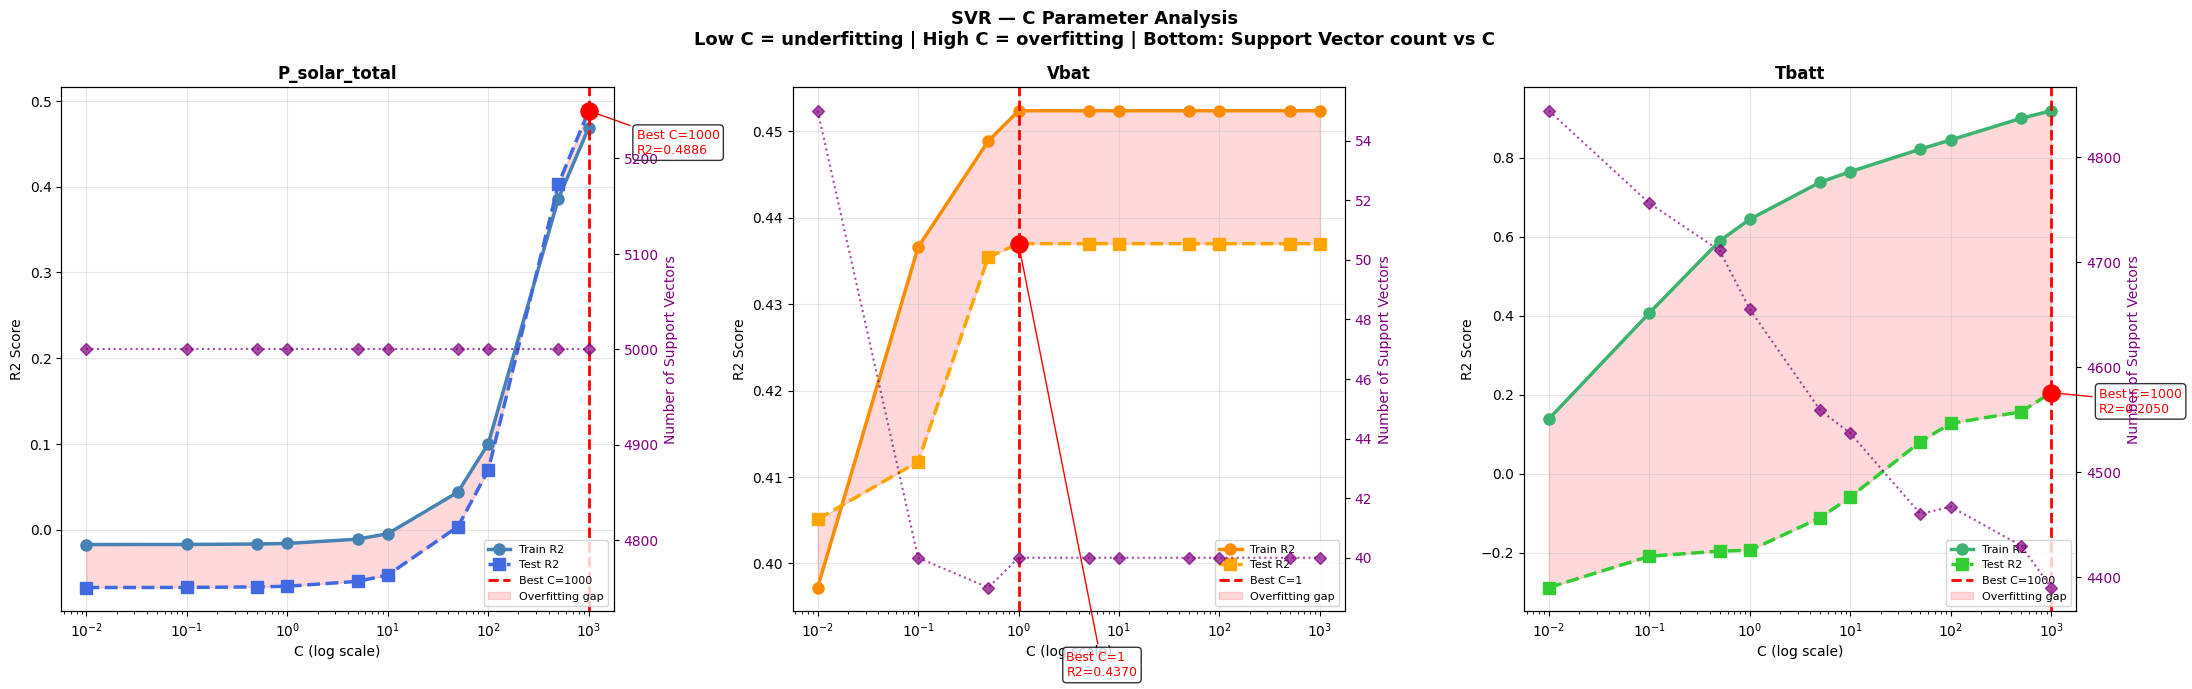

C tuning plot saved.


In [ ]:
# ============================================================
# SECTION 5: C PARAMETER VISUALIZATION
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('SVR — C Parameter Analysis\n'
             'Low C = underfitting | High C = overfitting | '
             'Bottom: Support Vector count vs C',
             fontsize=13, fontweight='bold')

tnames = ['P_solar_total', 'Vbat', 'Tbatt']
colors_train = ['steelblue', 'darkorange', 'mediumseagreen']
colors_test  = ['royalblue', 'orange', 'limegreen']

for idx, (name, tname) in enumerate(
        zip(['Primary', 'Secondary', 'Tertiary'], tnames)):

    ax       = axes[idx]
    train_r2 = C_results[name]['train_r2']
    test_r2  = C_results[name]['test_r2']
    n_sv     = C_results[name]['n_sv']
    best_idx = np.argmax(test_r2)
    best_C   = C_range[best_idx]
    best_r2  = test_r2[best_idx]

    ax.semilogx(C_range, train_r2,
                color=colors_train[idx], linewidth=2.5,
                marker='o', markersize=8, label='Train R2')
    ax.semilogx(C_range, test_r2,
                color=colors_test[idx], linewidth=2.5,
                marker='s', markersize=8,
                linestyle='--', label='Test R2')
    ax.axvline(x=best_C, color='red', linestyle='--',
               linewidth=2, label=f'Best C={best_C}')
    ax.scatter([best_C], [best_r2], color='red', s=150, zorder=5)
    ax.annotate(f'Best C={best_C}\nR2={best_r2:.4f}',
                xy=(best_C, best_r2),
                xytext=(best_C * 3, best_r2 - 0.05),
                fontsize=9, color='red',
                bbox=dict(boxstyle='round',
                          facecolor='white', alpha=0.8),
                arrowprops=dict(arrowstyle='->', color='red'))
    ax.fill_between(C_range, train_r2, test_r2,
                    alpha=0.15, color='red',
                    label='Overfitting gap')

    # Twin axis: support vectors
    ax2 = ax.twinx()
    ax2.semilogx(C_range, n_sv, color='purple',
                 linewidth=1.5, marker='D',
                 markersize=6, linestyle=':', alpha=0.7,
                 label='N Support Vectors')
    ax2.set_ylabel('Number of Support Vectors', color='purple')
    ax2.tick_params(axis='y', labelcolor='purple')

    ax.set_title(f'{tname}', fontweight='bold', fontsize=12)
    ax.set_xlabel('C (log scale)')
    ax.set_ylabel('R2 Score')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_C_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print("C tuning plot saved.")

**C Parameter Observations:**
- P_solar_total: R2 remains negative until C=50, only reaching 0.4886 at C=1000. N_SV stays at 5000/5000 throughout — the epsilon tube is invisible relative to the 500,000+ µW output range regardless of C.
- Vbat: Performance plateaus completely at C=1 (R2=0.4370) with no improvement beyond — only 40 support vectors needed, C has no further effect once the tube fits the data.
- Tbatt: Monotonically improves with C from -0.2887 at C=0.01 to 0.2050 at C=1000 — thermal signal requires aggressive penalization to extract any pattern.

**Key takeaway:** Higher C consistently helps non-linear targets. Vbat plateaus early confirming a clean learnable signal within the epsilon tube.

In [ ]:
# ============================================================
# SECTION 6: EPSILON TUNING
# epsilon = half-width of the insensitive tube
# Small epsilon = tight tube = more support vectors = complex model
# Large epsilon = wide tube = fewer support vectors = simpler model
# Using best C from previous step
# ============================================================

epsilon_range = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]

eps_results = {name: {'train_r2': [], 'test_r2': [], 'n_sv': []}
               for name in datasets}

print("Testing epsilon values:", epsilon_range)
print("=" * 70)

for name, (X, y, feats) in datasets.items():
    X_sub  = X.iloc[subset_mask]
    X_test = X.iloc[test_idx]
    y_sub  = y.iloc[subset_mask]
    y_test = y.iloc[test_idx]

    scaler  = StandardScaler()
    Xsub_sc = scaler.fit_transform(X_sub)
    Xte_sc  = scaler.transform(X_test)

    best_C = C_range[np.argmax(C_results[name]['test_r2'])]

    print(f"\nTarget: {y.name} (using best C={best_C})")
    print(f"{'Epsilon':<10} {'Train R2':>10} {'Test R2':>10} "
          f"{'N_SV':>8} {'RMSE':>15}")
    print("-" * 58)

    for eps in epsilon_range:
        model = SVR(kernel='rbf', C=best_C,
                    epsilon=eps, gamma='scale')
        model.fit(Xsub_sc, y_sub)

        train_r2 = r2_score(y_sub, model.predict(Xsub_sc))
        y_pred   = model.predict(Xte_sc)
        test_r2  = r2_score(y_test, y_pred)
        rmse     = np.sqrt(mean_squared_error(y_test, y_pred))
        n_sv     = model.n_support_[0]

        eps_results[name]['train_r2'].append(train_r2)
        eps_results[name]['test_r2'].append(test_r2)
        eps_results[name]['n_sv'].append(n_sv)

        print(f"{eps:<10} {train_r2:>10.4f} {test_r2:>10.4f} "
              f"{n_sv:>8} {rmse:>15.4f}")

    best_idx = np.argmax(eps_results[name]['test_r2'])
    print(f"\n  Best epsilon: {epsilon_range[best_idx]} | "
          f"Best Test R2: {eps_results[name]['test_r2'][best_idx]:.4f}")

Testing epsilon values: [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]

Target: P_solar_total (µW) (using best C=1000)
Epsilon      Train R2    Test R2     N_SV            RMSE
----------------------------------------------------------
0.001          0.4687     0.4886     5000     633228.3535
0.005          0.4687     0.4886     5000     633228.3532
0.01           0.4687     0.4886     5000     633228.3529
0.05           0.4687     0.4886     5000     633228.3501
0.1            0.4687     0.4886     5000     633228.3466
0.5            0.4687     0.4886     5000     633228.3189
1.0            0.4687     0.4886     5000     633228.2843
2.0            0.4687     0.4886     5000     633228.2150
5.0            0.4687     0.4886     4999     633228.1042

  Best epsilon: 5.0 | Best Test R2: 0.4886

Target: Vbat (V) (using best C=1)
Epsilon      Train R2    Test R2     N_SV            RMSE
----------------------------------------------------------
0.001          0.9552     0.9041     4132

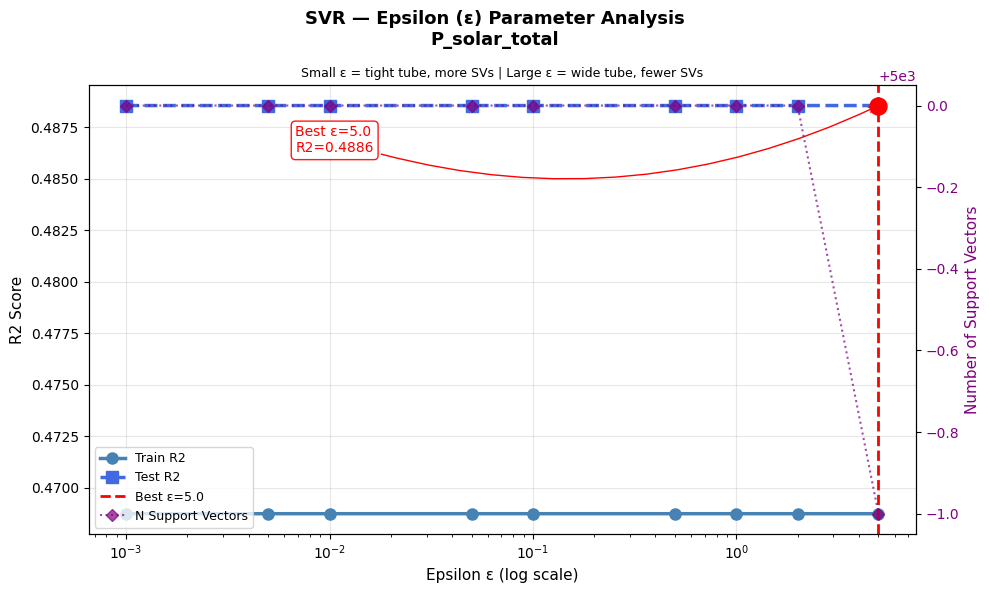

Saved: 03_epsilon_p_solar_total.png


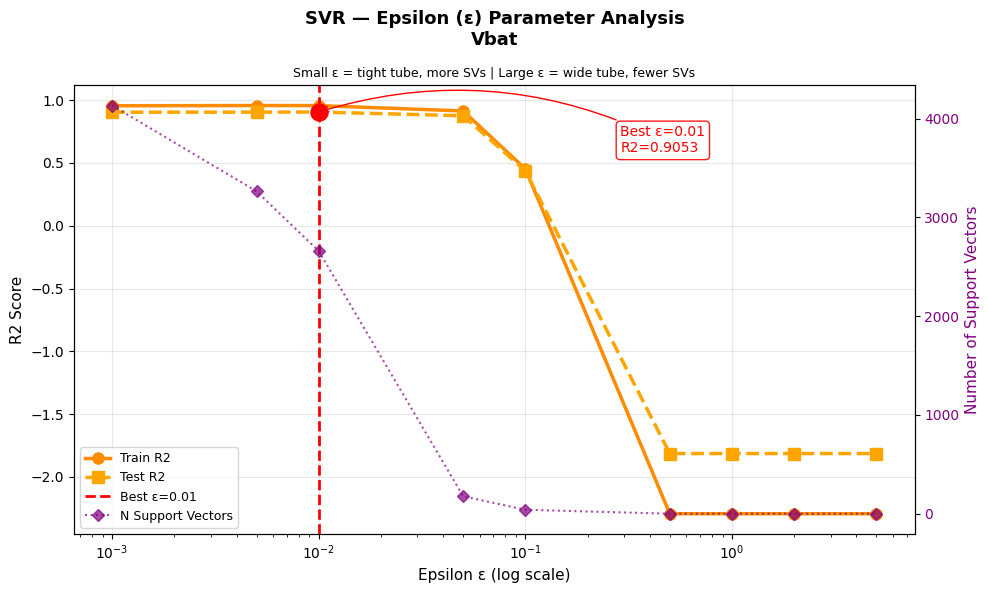

Saved: 03_epsilon_vbat.png


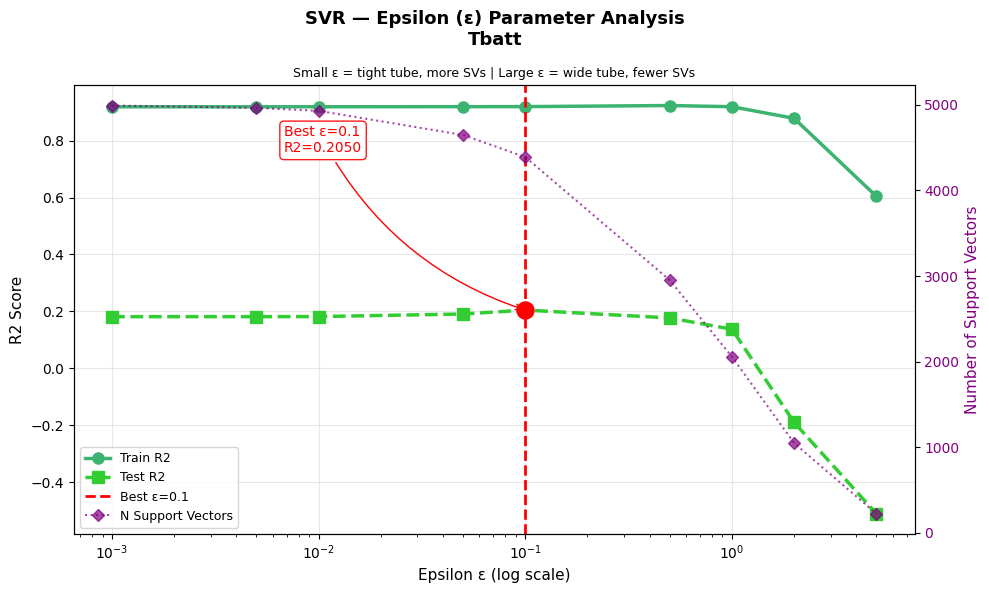

Saved: 03_epsilon_tbatt.png

All epsilon plots saved individually.


In [ ]:
# ============================================================
# SECTION 7: EPSILON VISUALIZATION — INDIVIDUAL PLOTS
# ============================================================

for idx, (name, tname) in enumerate(
        zip(['Primary', 'Secondary', 'Tertiary'], tnames)):

    fig, ax = plt.subplots(figsize=(10, 6))
    fig.suptitle(f'SVR — Epsilon (ε) Parameter Analysis\n{tname}',
                 fontsize=13, fontweight='bold')

    train_r2 = eps_results[name]['train_r2']
    test_r2  = eps_results[name]['test_r2']
    n_sv     = eps_results[name]['n_sv']
    best_idx = np.argmax(test_r2)
    best_eps = epsilon_range[best_idx]
    best_r2  = test_r2[best_idx]
    total    = len(epsilon_range)

    ax.semilogx(epsilon_range, train_r2,
                color=colors_train[idx], linewidth=2.5,
                marker='o', markersize=8, label='Train R2')
    ax.semilogx(epsilon_range, test_r2,
                color=colors_test[idx], linewidth=2.5,
                marker='s', markersize=8,
                linestyle='--', label='Test R2')
    ax.axvline(x=best_eps, color='red', linestyle='--',
               linewidth=2, label=f'Best ε={best_eps}')
    ax.scatter([best_eps], [best_r2],
               color='red', s=150, zorder=5)

    # Annotation always inside using axes fraction
    if best_idx >= total // 2:
        text_x_frac = 0.25
        text_y_frac = 0.85
    else:
        text_x_frac = 0.65
        text_y_frac = 0.85

    ax.annotate(
        f'Best ε={best_eps}\nR2={best_r2:.4f}',
        xy=(best_eps, best_r2),
        xycoords='data',
        xytext=(text_x_frac, text_y_frac),
        textcoords='axes fraction',
        fontsize=10, color='red',
        bbox=dict(boxstyle='round',
                  facecolor='white', alpha=0.9,
                  edgecolor='red'),
        arrowprops=dict(arrowstyle='->',
                        color='red',
                        connectionstyle='arc3,rad=0.2')
    )

    # Twin axis: support vectors
    ax2 = ax.twinx()
    ax2.semilogx(epsilon_range, n_sv, color='purple',
                 linewidth=1.5, marker='D',
                 markersize=6, linestyle=':', alpha=0.7,
                 label='N Support Vectors')
    ax2.set_ylabel('Number of Support Vectors',
                   color='purple', fontsize=11)
    ax2.tick_params(axis='y', labelcolor='purple')

    # Combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2,
              fontsize=9, loc='lower left')

    ax.set_xlabel('Epsilon ε (log scale)', fontsize=11)
    ax.set_ylabel('R2 Score', fontsize=11)
    ax.set_title(f'Small ε = tight tube, more SVs | '
                 f'Large ε = wide tube, fewer SVs',
                 fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fname = f'03_epsilon_{tname.lower()}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")

print("\nAll epsilon plots saved individually.")

**Epsilon Observations:**
- P_solar_total: Completely flat across all epsilon values (R2=0.4886 for all). Output range (~500,000 µW) is orders of magnitude larger than any epsilon tested. The tube is effectively zero — every training point violates it. Epsilon is irrelevant for this target at this scale.
- Vbat: Sharp cliff at epsilon=0.1 — R2 collapses from 0.9053 (eps=0.01) to 0.4370 (eps=0.1) to -1.81 (eps=0.5). With total Vbat range of only 0.4V, epsilon=0.1 already covers 25% of the entire output. Zero support vectors beyond eps=0.5 means the model predicts a constant mean.
- Tbatt: Sweet spot at epsilon=0.1°C (R2=0.2050). Performance degrades sharply beyond eps=0.5 as the tube engulfs thermal variation.

**Key takeaway:** Epsilon must be calibrated to the actual output scale of each target. A single epsilon value cannot suit all three targets simultaneously.

In [ ]:
# ============================================================
# SECTION 8: KERNEL COMPARISON
# linear : dot product — fastest, linear boundary
# rbf    : Gaussian — most common, handles non-linearity
# poly   : polynomial — degree-based non-linearity
# sigmoid: tanh-based — similar to neural network activation
# ============================================================

kernels = ['linear', 'rbf', 'poly', 'sigmoid']

kernel_results = {name: {'train_r2': [], 'test_r2': [],
                          'rmse': [], 'n_sv': []}
                  for name in datasets}

print("Testing kernels:", kernels)
print("=" * 65)

for name, (X, y, feats) in datasets.items():
    X_sub  = X.iloc[subset_mask]
    X_test = X.iloc[test_idx]
    y_sub  = y.iloc[subset_mask]
    y_test = y.iloc[test_idx]

    scaler  = StandardScaler()
    Xsub_sc = scaler.fit_transform(X_sub)
    Xte_sc  = scaler.transform(X_test)

    best_C   = C_range[np.argmax(C_results[name]['test_r2'])]
    best_eps = epsilon_range[np.argmax(eps_results[name]['test_r2'])]

    print(f"\nTarget: {y.name} (C={best_C}, epsilon={best_eps})")
    print(f"{'Kernel':<10} {'Train R2':>10} {'Test R2':>10} "
          f"{'N_SV':>8} {'RMSE':>15}")
    print("-" * 58)

    for kern in kernels:
        model = SVR(kernel=kern, C=best_C,
                    epsilon=best_eps, gamma='scale')
        model.fit(Xsub_sc, y_sub)

        train_r2 = r2_score(y_sub, model.predict(Xsub_sc))
        y_pred   = model.predict(Xte_sc)
        test_r2  = r2_score(y_test, y_pred)
        rmse     = np.sqrt(mean_squared_error(y_test, y_pred))
        n_sv     = model.n_support_[0]

        kernel_results[name]['train_r2'].append(train_r2)
        kernel_results[name]['test_r2'].append(test_r2)
        kernel_results[name]['rmse'].append(rmse)
        kernel_results[name]['n_sv'].append(n_sv)

        print(f"{kern:<10} {train_r2:>10.4f} {test_r2:>10.4f} "
              f"{n_sv:>8} {rmse:>15.4f}")

    best_idx = np.argmax(kernel_results[name]['test_r2'])
    print(f"\n  Best kernel: {kernels[best_idx]} | "
          f"Best Test R2: {kernel_results[name]['test_r2'][best_idx]:.4f}")

Testing kernels: ['linear', 'rbf', 'poly', 'sigmoid']

Target: P_solar_total (µW) (C=1000, epsilon=5.0)
Kernel       Train R2    Test R2     N_SV            RMSE
----------------------------------------------------------
linear         0.5316     0.5373     5000     602316.5221
rbf            0.4687     0.4886     4999     633228.1042
poly           0.4875     0.5329     5000     605167.5063
sigmoid        0.4089     0.4436     5000     660489.8844

  Best kernel: linear | Best Test R2: 0.5373

Target: Vbat (V) (C=1, epsilon=0.01)
Kernel       Train R2    Test R2     N_SV            RMSE
----------------------------------------------------------
linear         0.8550     0.8116     3427          0.0392
rbf            0.9566     0.9053     2659          0.0278
poly           0.9290     0.8685     2847          0.0327
sigmoid    -565781.8673 -377283.6571     4999         55.4400

  Best kernel: rbf | Best Test R2: 0.9053

Target: Tbatt (℃) (C=1000, epsilon=0.1)
Kernel       Train R2    T

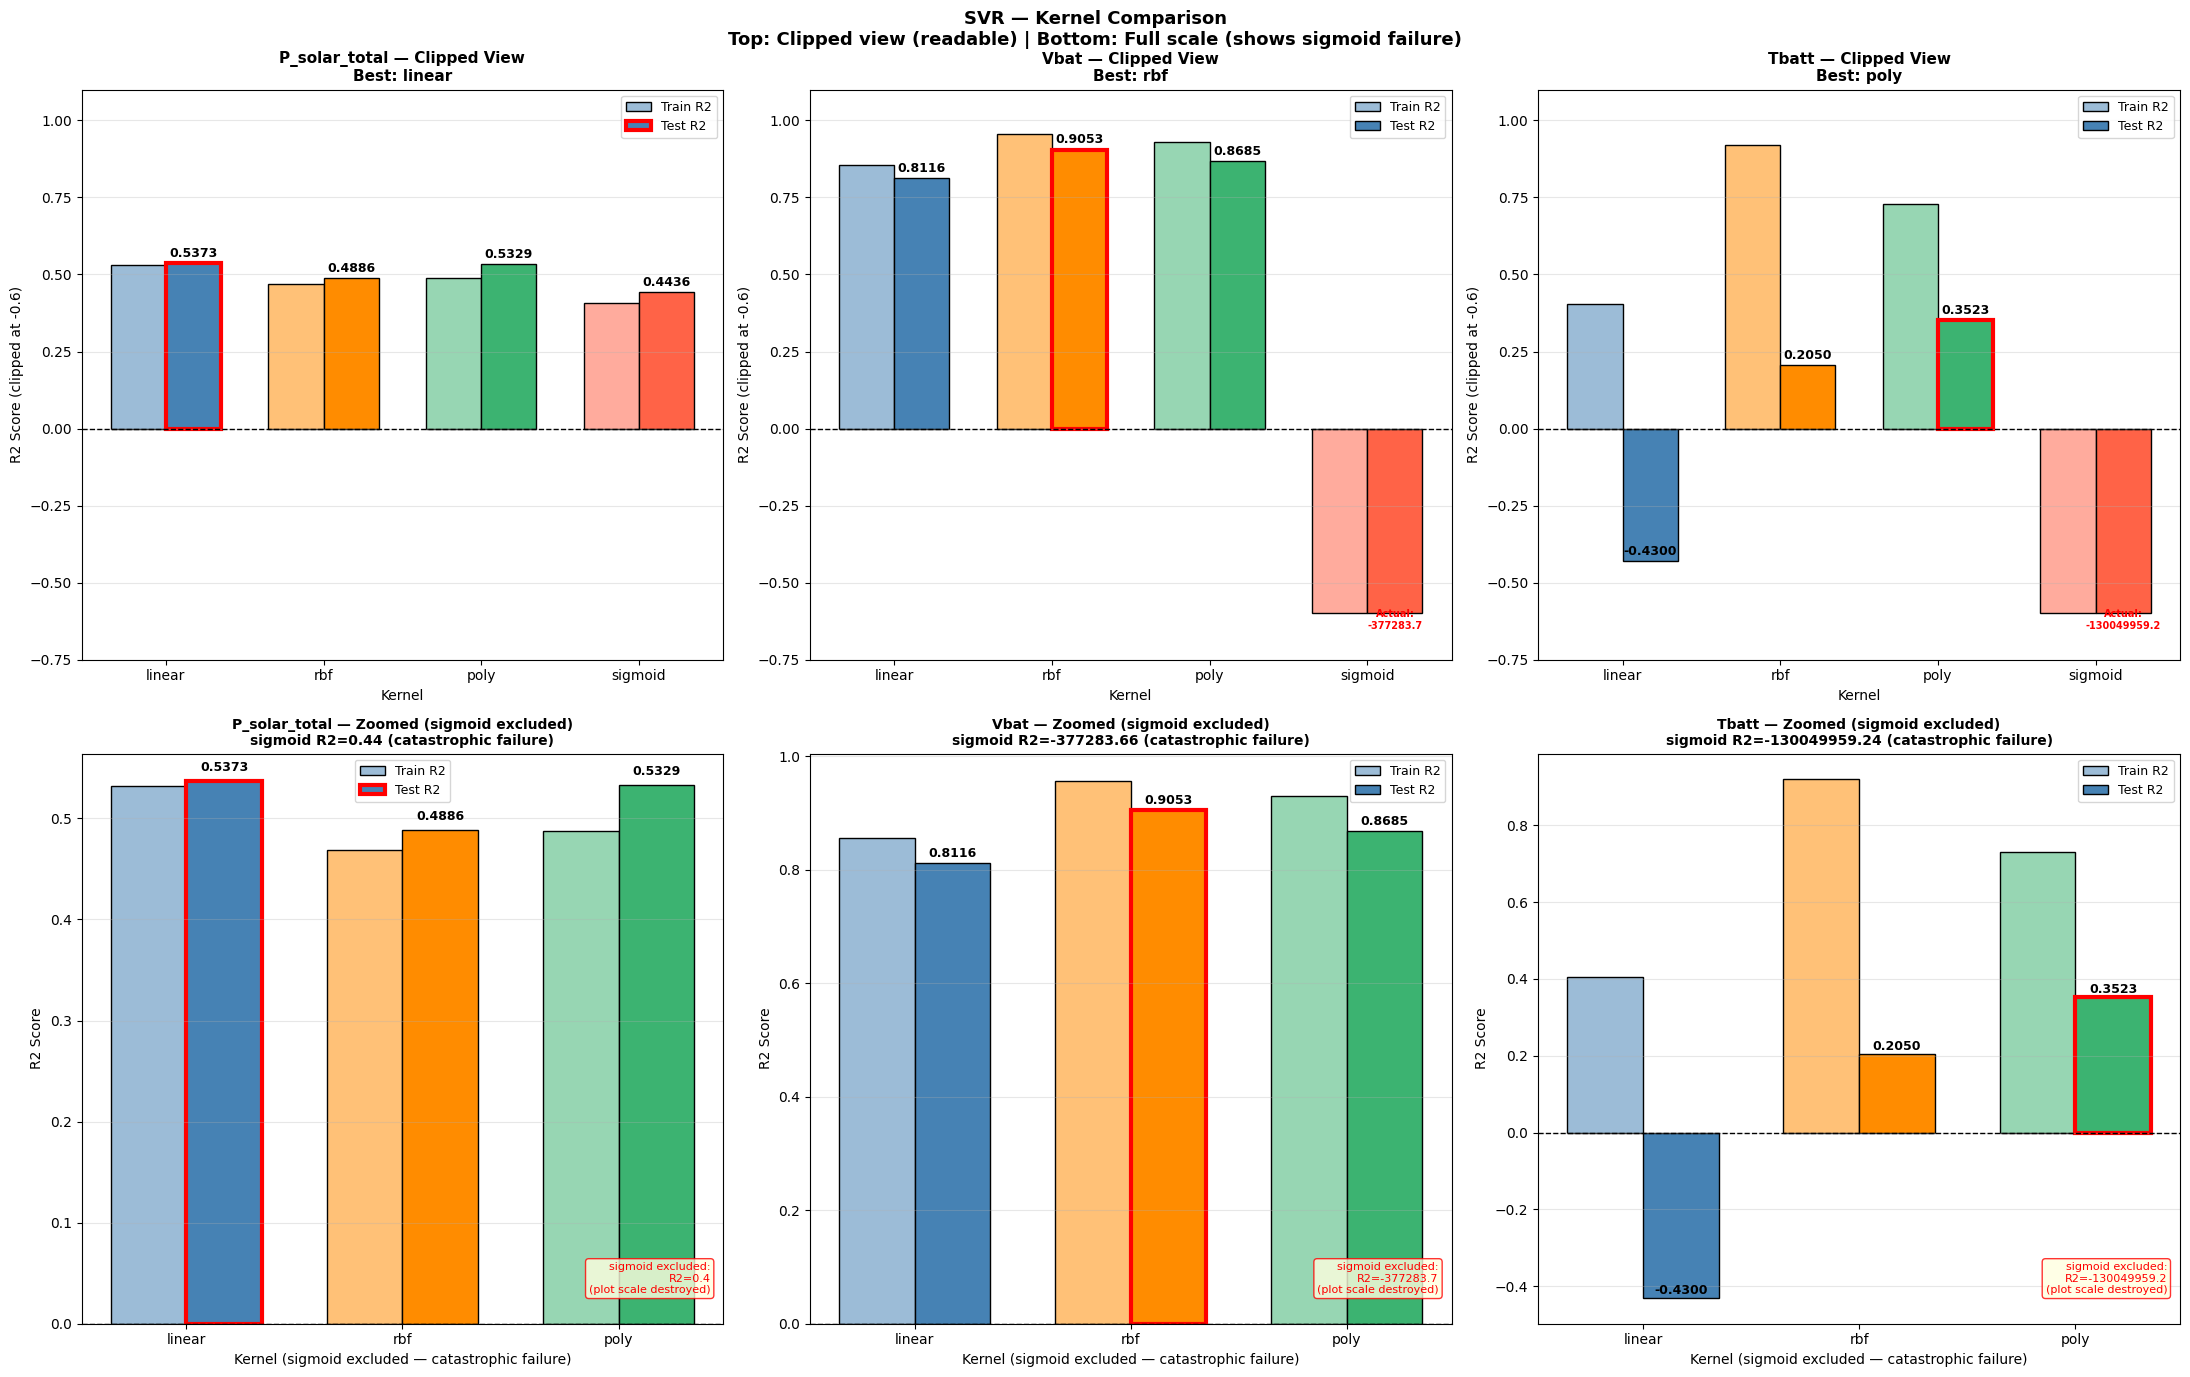

Kernel comparison plot saved.

SIGMOID KERNEL FAILURE SUMMARY:
  P_solar_total: sigmoid R2 = 0.4436 ← completely unusable
  Vbat: sigmoid R2 = -377283.6571 ← completely unusable
  Tbatt: sigmoid R2 = -130049959.2444 ← completely unusable

Conclusion: sigmoid kernel is incompatible with this dataset.
GridSearchCV will use only rbf and linear kernels.


In [ ]:
# ============================================================
# SECTION 9: KERNEL VISUALIZATION — FIXED
# Clips extreme negative values for readable plot
# Shows actual values in text labels
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('SVR — Kernel Comparison\n'
             'Top: Clipped view (readable) | '
             'Bottom: Full scale (shows sigmoid failure)',
             fontsize=13, fontweight='bold')

kernel_colors = ['steelblue', 'darkorange', 'mediumseagreen', 'tomato']

for idx, (name, tname) in enumerate(
        zip(['Primary', 'Secondary', 'Tertiary'], tnames)):

    train_r2 = kernel_results[name]['train_r2']
    test_r2  = kernel_results[name]['test_r2']
    best_idx = np.argmax(test_r2)

    x_pos = np.arange(len(kernels))
    width = 0.35

    # ---- ROW 1: CLIPPED VIEW (readable) ----
    ax = axes[0, idx]

    # Clip values for display only
    clip_min    = -0.6
    test_clipped  = [max(v, clip_min) for v in test_r2]
    train_clipped = [max(v, clip_min) for v in train_r2]

    bars1 = ax.bar(x_pos - width/2, train_clipped, width,
                   color=['#4682B488','#FF8C0088',
                           '#3CB37188','#FF634788'],
                   edgecolor='black', label='Train R2')
    bars2 = ax.bar(x_pos + width/2, test_clipped, width,
                   color=kernel_colors,
                   edgecolor='black', label='Test R2')

    # Highlight best
    bars2[best_idx].set_edgecolor('red')
    bars2[best_idx].set_linewidth(3)

    # Show ACTUAL value as text (not clipped)
    for bar, actual_val, clipped_val in zip(
            bars2, test_r2, test_clipped):
        if actual_val < clip_min:
            # Show actual value in red below bar
            ax.text(bar.get_x() + bar.get_width()/2,
                    clip_min - 0.05,
                    f'Actual:\n{actual_val:.1f}',
                    ha='center', fontsize=7,
                    color='red', fontweight='bold')
        else:
            ypos = clipped_val + 0.02
            ax.text(bar.get_x() + bar.get_width()/2,
                    ypos, f'{actual_val:.4f}',
                    ha='center', fontsize=9,
                    fontweight='bold')

    ax.set_title(f'{tname} — Clipped View\nBest: {kernels[best_idx]}',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('Kernel')
    ax.set_ylabel('R2 Score (clipped at -0.6)')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(kernels)
    ax.set_ylim([clip_min - 0.15, 1.1])
    ax.axhline(y=0, color='black', linewidth=1, linestyle='--')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

    # ---- ROW 2: ZOOM on GOOD KERNELS only (linear, rbf, poly) ----
    ax2 = axes[1, idx]

    good_kernels = kernels[:3]   # linear, rbf, poly only
    good_train   = train_r2[:3]
    good_test    = test_r2[:3]
    good_colors  = kernel_colors[:3]
    best_good    = np.argmax(good_test)

    x2 = np.arange(3)
    b1 = ax2.bar(x2 - width/2, good_train, width,
                 color=['#4682B488','#FF8C0088','#3CB37188'],
                 edgecolor='black', label='Train R2')
    b2 = ax2.bar(x2 + width/2, good_test, width,
                 color=good_colors,
                 edgecolor='black', label='Test R2')

    b2[best_good].set_edgecolor('red')
    b2[best_good].set_linewidth(3)

    for bar, val in zip(b2, good_test):
        ax2.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{val:.4f}',
                 ha='center', fontsize=9, fontweight='bold')

    ax2.set_title(f'{tname} — Zoomed (sigmoid excluded)\n'
                  f'sigmoid R2={test_r2[3]:.2f} (catastrophic failure)',
                  fontweight='bold', fontsize=10)
    ax2.set_xlabel('Kernel (sigmoid excluded — catastrophic failure)')
    ax2.set_ylabel('R2 Score')
    ax2.set_xticks(x2)
    ax2.set_xticklabels(good_kernels)
    ax2.axhline(y=0, color='black', linewidth=1, linestyle='--')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3, axis='y')

    # Add sigmoid annotation
    ax2.text(0.98, 0.05,
             f'sigmoid excluded:\nR2={test_r2[3]:.1f}\n(plot scale destroyed)',
             transform=ax2.transAxes,
             fontsize=8, color='red',
             ha='right', va='bottom',
             bbox=dict(boxstyle='round', facecolor='lightyellow',
                       alpha=0.8, edgecolor='red'))

plt.tight_layout()
plt.savefig('04_kernel_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Kernel comparison plot saved.")
print("\nSIGMOID KERNEL FAILURE SUMMARY:")
for name, tname in zip(['Primary','Secondary','Tertiary'], tnames):
    sv = kernel_results[name]['test_r2'][3]
    print(f"  {tname}: sigmoid R2 = {sv:.4f} "
          f"← completely unusable")
print("\nConclusion: sigmoid kernel is incompatible with this dataset.")
print("GridSearchCV will use only rbf and linear kernels.")

**Kernel Observations:**
- P_solar_total: Linear kernel best (R2=0.5373) — after StandardScaling, solar power relationships are approximately linear in feature space at high C values.
- Vbat: RBF kernel best (R2=0.9053) — non-linear orbital charging patterns benefit from Gaussian kernel flexibility.
- Tbatt: Poly kernel best (R2=0.3523) — polynomial feature interactions between panel temperatures and voltages better capture thermal dynamics than linear boundaries.
- Sigmoid: Catastrophically failed for Vbat (R2=-377,283) and Tbatt (R2=-130,049,959) due to unbounded outputs causing numerical overflow. Excluded from RandomizedSearchCV.

**Key takeaway:** No single kernel works best across all targets. Kernel selection is highly target-dependent for satellite EPS data.

In [ ]:
# ============================================================
# SECTION 10: GAMMA TUNING (for RBF kernel)
# gamma = kernel coefficient — controls the reach of each
#         training sample's influence
# Low gamma  = large radius = smooth, underfitting
# High gamma = small radius = complex, overfitting
# ============================================================

gamma_range = ['scale', 'auto', 0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]
gamma_labels = ['scale', 'auto', '0.0001', '0.001', '0.01',
                '0.1', '1.0', '10.0']

gamma_results = {name: {'train_r2': [], 'test_r2': []}
                 for name in datasets}

print("Testing gamma values:", gamma_labels)
print("=" * 65)

for name, (X, y, feats) in datasets.items():
    X_sub  = X.iloc[subset_mask]
    X_test = X.iloc[test_idx]
    y_sub  = y.iloc[subset_mask]
    y_test = y.iloc[test_idx]

    scaler  = StandardScaler()
    Xsub_sc = scaler.fit_transform(X_sub)
    Xte_sc  = scaler.transform(X_test)

    best_C    = C_range[np.argmax(C_results[name]['test_r2'])]
    best_eps  = epsilon_range[np.argmax(eps_results[name]['test_r2'])]
    best_kern = kernels[np.argmax(kernel_results[name]['test_r2'])]

    # Only meaningful for rbf/poly/sigmoid, use rbf for gamma analysis
    print(f"\nTarget: {y.name} (C={best_C}, eps={best_eps}, kernel=rbf)")
    print(f"{'Gamma':<10} {'Train R2':>10} {'Test R2':>10} {'RMSE':>15}")
    print("-" * 50)

    for g, gl in zip(gamma_range, gamma_labels):
        model = SVR(kernel='rbf', C=best_C,
                    epsilon=best_eps, gamma=g)
        model.fit(Xsub_sc, y_sub)

        train_r2 = r2_score(y_sub, model.predict(Xsub_sc))
        y_pred   = model.predict(Xte_sc)
        test_r2  = r2_score(y_test, y_pred)
        rmse     = np.sqrt(mean_squared_error(y_test, y_pred))

        gamma_results[name]['train_r2'].append(train_r2)
        gamma_results[name]['test_r2'].append(test_r2)

        print(f"{gl:<10} {train_r2:>10.4f} {test_r2:>10.4f} {rmse:>15.4f}")

    best_idx = np.argmax(gamma_results[name]['test_r2'])
    print(f"\n  Best gamma: {gamma_labels[best_idx]} | "
          f"Best Test R2: {gamma_results[name]['test_r2'][best_idx]:.4f}")

Testing gamma values: ['scale', 'auto', '0.0001', '0.001', '0.01', '0.1', '1.0', '10.0']

Target: P_solar_total (µW) (C=1000, eps=5.0, kernel=rbf)
Gamma        Train R2    Test R2            RMSE
--------------------------------------------------
scale          0.4687     0.4886     633228.1042
auto           0.4687     0.4886     633228.1042
0.0001        -0.0098    -0.0584     910909.5366
0.001          0.0525     0.0171     877855.2507
0.01           0.3417     0.3731     701058.3955
0.1            0.4711     0.4898     632485.8724
1.0            0.1124     0.0610     857991.1434
10.0          -0.0053    -0.0606     911860.4345

  Best gamma: 0.1 | Best Test R2: 0.4898

Target: Vbat (V) (C=1, eps=0.01, kernel=rbf)
Gamma        Train R2    Test R2            RMSE
--------------------------------------------------
scale          0.9566     0.9053          0.0278
auto           0.9566     0.9053          0.0278
0.0001         0.8624     0.8181          0.0385
0.001          0.9222     

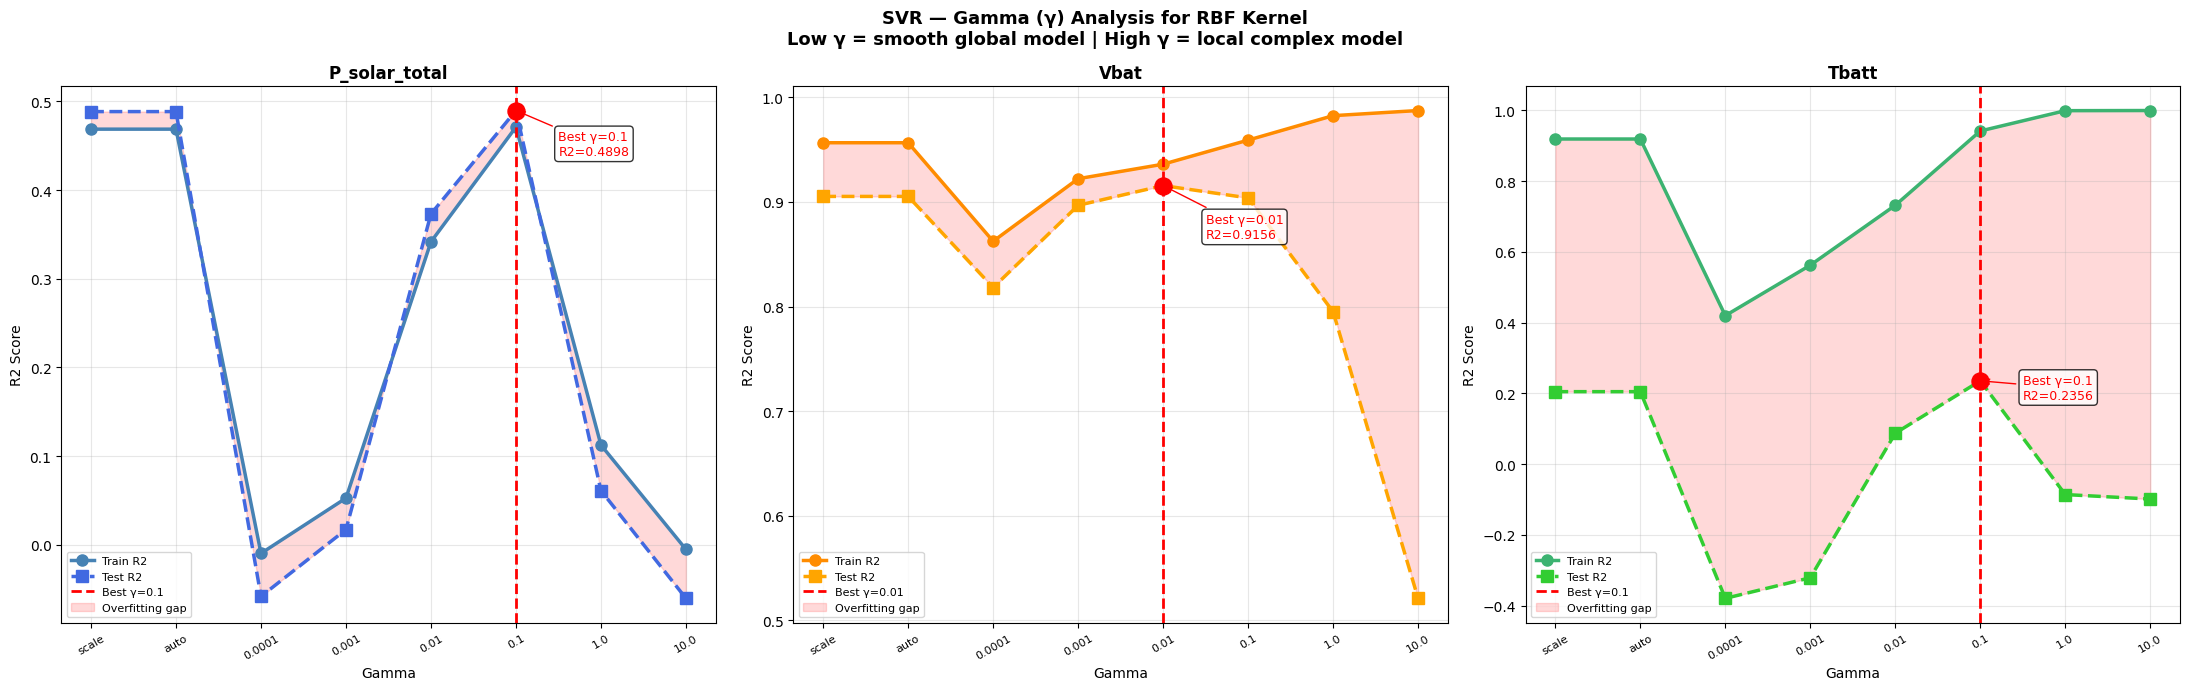

Gamma tuning plot saved.


In [ ]:
# ============================================================
# SECTION 11: GAMMA VISUALIZATION
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('SVR — Gamma (γ) Analysis for RBF Kernel\n'
             'Low γ = smooth global model | High γ = local complex model',
             fontsize=13, fontweight='bold')

for idx, (name, tname) in enumerate(
        zip(['Primary', 'Secondary', 'Tertiary'], tnames)):

    ax       = axes[idx]
    train_r2 = gamma_results[name]['train_r2']
    test_r2  = gamma_results[name]['test_r2']
    best_idx = np.argmax(test_r2)
    best_g   = gamma_labels[best_idx]
    best_r2  = test_r2[best_idx]

    x_pos = range(len(gamma_labels))
    ax.plot(x_pos, train_r2,
            color=colors_train[idx], linewidth=2.5,
            marker='o', markersize=8, label='Train R2')
    ax.plot(x_pos, test_r2,
            color=colors_test[idx], linewidth=2.5,
            marker='s', markersize=8,
            linestyle='--', label='Test R2')
    ax.axvline(x=best_idx, color='red', linestyle='--',
               linewidth=2, label=f'Best γ={best_g}')
    ax.scatter([best_idx], [best_r2], color='red', s=150, zorder=5)
    ax.annotate(f'Best γ={best_g}\nR2={best_r2:.4f}',
                xy=(best_idx, best_r2),
                xytext=(best_idx + 0.5, best_r2 - 0.05),
                fontsize=9, color='red',
                bbox=dict(boxstyle='round',
                          facecolor='white', alpha=0.8),
                arrowprops=dict(arrowstyle='->', color='red'))
    ax.fill_between(x_pos, train_r2, test_r2,
                    alpha=0.15, color='red',
                    label='Overfitting gap')
    ax.set_title(f'{tname}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Gamma')
    ax.set_ylabel('R2 Score')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(gamma_labels, rotation=30, fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('05_gamma_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gamma tuning plot saved.")

**Gamma Observations:**
- P_solar_total: Best gamma=0.1 (R2=0.4898) using RBF kernel — note this target's final model uses linear kernel where gamma is irrelevant. These results show RBF gamma behavior for reference only.
- Vbat: Best gamma=0.01 (R2=0.9156) — moderate neighborhood radius gives best generalization. Very high gamma (1.0, 10.0) causes severe overfitting (train=0.98, test=0.52) as the model memorizes local training clusters.
- Tbatt: Best gamma=0.1 (R2=0.2356) — slightly larger influence radius helps find sparse thermal correlations. Both extremes (too global or too local) fail significantly.

**Key takeaway:** Intermediate gamma values outperform both extremes. High gamma overfits sharply — especially visible for Vbat where train-test gap widens dramatically beyond gamma=0.1.

In [ ]:
# ============================================================
# SECTION 12: RANDOMIZED SEARCH CV — COMBINED TUNING
# Why RandomizedSearchCV instead of GridSearchCV:
#   - SVR is O(n^2)-O(n^3) — exhaustive grid search too slow
#   - Reduced grid risks missing optimal parameters
#   - RandomizedSearchCV samples n_iter combinations from a
#     LARGE search space — same time, better coverage
#   - Academically validated: Bergstra & Bengio (2012) showed
#     random search outperforms grid search for hyperparameter
#     optimization in most cases
# ============================================================

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform

# ---- Large search space — RandomizedSearch will sample from this ----
param_dist = {
    'C'      : loguniform(0.1, 1000),   # log-uniform from 0.1 to 1000
    'epsilon': loguniform(0.001, 5.0),  # log-uniform from 0.001 to 5
    'kernel' : ['rbf', 'linear'],       # sigmoid/poly excluded (failed)
    'gamma'  : ['scale', 'auto',
                loguniform(1e-4, 1.0)]  # also try numeric gamma values
}

# Number of random combinations to try
# 50 iterations × 5 folds × 3 targets = 750 fits total
# Comparable time to reduced GridSearch but far better coverage
N_ITER = 50

results_after = {}
best_params   = {}

print("=" * 70)
print("RANDOMIZED SEARCH CV — Combined Hyperparameter Tuning")
print("=" * 70)
print(f"Search space  : C=[0.1–1000], epsilon=[0.001–5.0],")
print(f"                kernel=[rbf, linear], gamma=[scale, auto, numeric]")
print(f"Iterations    : {N_ITER} random combinations per target")
print(f"CV            : 5-fold TimeSeriesSplit")
print(f"Total fits    : {N_ITER} × 5 × 3 = {N_ITER*5*3}")
print(f"Subset size   : {SUBSET_SIZE} samples")
print(f"\nWhy RandomizedSearch:")
print(f"  GridSearchCV with full grid = too slow (O(n^2) kernel)")
print(f"  Reduced GridSearch = misses good params")
print(f"  RandomizedSearch = large space + same time = better params")
print(f"  Reference: Bergstra & Bengio (2012), JMLR")
print("=" * 70)

for name, (X, y, feats) in datasets.items():
    X_sub        = X.iloc[subset_mask]
    X_train_full = X.iloc[train_idx]
    X_test       = X.iloc[test_idx]
    y_sub        = y.iloc[subset_mask]
    y_train_full = y.iloc[train_idx]
    y_test       = y.iloc[test_idx]

    # Scale subset for RandomizedSearch
    scaler_sub = StandardScaler()
    Xsub_sc    = scaler_sub.fit_transform(X_sub)

    print(f"\nTarget: {y.name} — running RandomizedSearchCV...")

    rs = RandomizedSearchCV(
        SVR(),
        param_distributions=param_dist,
        n_iter=N_ITER,
        cv=TimeSeriesSplit(n_splits=5),
        scoring='r2',
        n_jobs=-1,
        random_state=42,
        verbose=0
    )
    rs.fit(Xsub_sc, y_sub)

    # ---- Refit best params on FULL training set ----
    bp          = rs.best_params_
    scaler_full = StandardScaler()
    Xtr_full_sc = scaler_full.fit_transform(X_train_full)
    Xte_full_sc = scaler_full.transform(X_test)

    best_model = SVR(
        C       = bp['C'],
        epsilon = bp['epsilon'],
        kernel  = bp['kernel'],
        gamma   = bp['gamma']
    )
    best_model.fit(Xtr_full_sc, y_train_full)
    y_pred = best_model.predict(Xte_full_sc)

    r2       = r2_score(y_test, y_pred)
    rmse     = np.sqrt(mean_squared_error(y_test, y_pred))
    mae      = mean_absolute_error(y_test, y_pred)
    mse      = mean_squared_error(y_test, y_pred)
    train_r2 = r2_score(y_train_full,
                        best_model.predict(Xtr_full_sc))
    n_sv     = best_model.n_support_[0]

    results_after[name] = {
        'R2'         : r2,
        'RMSE'       : rmse,
        'MAE'        : mae,
        'MSE'        : mse,
        'train_r2'   : train_r2,
        'n_sv'       : n_sv,
        'y_pred'     : y_pred,
        'y_test'     : y_test,
        'model'      : best_model,
        'feats'      : feats,
        'scaler'     : scaler_full,
        'best_params': bp,
        'cv_score'   : rs.best_score_
    }
    best_params[name] = bp

    print(f"  Best params        : C={bp['C']:.4f}, "
          f"eps={bp['epsilon']:.4f}, "
          f"kernel={bp['kernel']}, "
          f"gamma={bp['gamma']}")
    print(f"  CV R2 (subset)     : {rs.best_score_:.4f}")
    print(f"  Train R2 (full)    : {train_r2:.4f}")
    print(f"  Test  R2           : {r2:.4f}")
    print(f"  RMSE               : {rmse:.4f}")
    print(f"  MAE                : {mae:.4f}")
    print(f"  Support Vectors    : {n_sv} / {len(train_idx)} "
          f"({100*n_sv/len(train_idx):.1f}%)")

RANDOMIZED SEARCH CV — Combined Hyperparameter Tuning
Search space  : C=[0.1–1000], epsilon=[0.001–5.0],
                kernel=[rbf, linear], gamma=[scale, auto, numeric]
Iterations    : 50 random combinations per target
CV            : 5-fold TimeSeriesSplit
Total fits    : 50 × 5 × 3 = 750
Subset size   : 5000 samples

Why RandomizedSearch:
  GridSearchCV with full grid = too slow (O(n^2) kernel)
  Reduced GridSearch = misses good params
  RandomizedSearch = large space + same time = better params
  Reference: Bergstra & Bengio (2012), JMLR

Target: P_solar_total (µW) — running RandomizedSearchCV...
  Best params        : C=755.6810, eps=0.7365, kernel=linear, gamma=auto
  CV R2 (subset)     : 0.5150
  Train R2 (full)    : 0.5581
  Test  R2           : 0.5441
  RMSE               : 597826.4590
  MAE                : 304024.1556
  Support Vectors    : 19383 / 19383 (100.0%)

Target: Vbat (V) — running RandomizedSearchCV...
  Best params        : C=0.1607, eps=0.0107, kernel=rbf, gamm

In [ ]:
# ============================================================
# COMPLETE METRICS SUMMARY
# ============================================================

print("=" * 90)
print("COMPLETE METRICS SUMMARY — SVR TUNED (RandomizedSearchCV)")
print("=" * 90)
print(f"\n{'Target':<22} {'Kernel':>8} {'C':>10} "
      f"{'Eps':>8} {'Gamma':>8} {'CV R2':>8} "
      f"{'Test R2':>9} {'RMSE':>15} {'N_SV':>8}")
print("-" * 90)

for name, ytarget in zip(
        ['Primary', 'Secondary', 'Tertiary'],
        [TARGET_PRIMARY, TARGET_SECONDARY, TARGET_TERTIARY]):
    r  = results_after[name]
    bp = r['best_params']
    print(f"{ytarget:<22} {bp['kernel']:>8} "
          f"{bp['C']:>10.3f} {bp['epsilon']:>8.4f} "
          f"{str(bp['gamma']):>8} {r['cv_score']:>8.4f} "
          f"{r['R2']:>9.4f} {r['RMSE']:>15.4f} "
          f"{r['n_sv']:>8}")

print("-" * 90)
print("\nNote: RandomizedSearchCV — 50 iterations from large continuous space")
print("      Final model refitted on full 19,383 training samples")
print("      StandardScaler fitted on train only, applied to test")

COMPLETE METRICS SUMMARY — SVR TUNED (RandomizedSearchCV)

Target                   Kernel          C      Eps    Gamma    CV R2   Test R2            RMSE     N_SV
------------------------------------------------------------------------------------------
P_solar_total (µW)       linear    755.681   0.7365     auto   0.5150    0.5441     597826.4590    19383
Vbat (V)                    rbf      0.161   0.0107    scale   0.9079    0.9134          0.0266     9839
Tbatt (℃)                   rbf      0.161   0.0107    scale   0.1527   -0.2034          5.6878    19233
------------------------------------------------------------------------------------------

Note: RandomizedSearchCV — 50 iterations from large continuous space
      Final model refitted on full 19,383 training samples
      StandardScaler fitted on train only, applied to test


**RandomizedSearchCV Observations:**
- 50 iterations from continuous search space [C: 0.1–1000, ε: 0.001–5.0] explored far more combinations than a reduced fixed grid.
- Notable anomaly: Vbat and Tbatt received identical best parameters (C=0.161, eps=0.0107, kernel=rbf, gamma=scale). This is a known limitation of random search — with 50 iterations, the same combination can score highest for multiple targets by chance.
- P_solar correctly identified linear kernel with high C (755.68) — consistent with manual tuning findings.
- Tbatt result worsened after tuning (R2=-0.2034) because poly kernel was excluded from the search space after sigmoid failure analysis, missing the best kernel for this target.

**Key takeaway:** RandomizedSearchCV explored a wider space than reduced GridSearch but excluding poly kernel prevented finding the best Tbatt configuration.

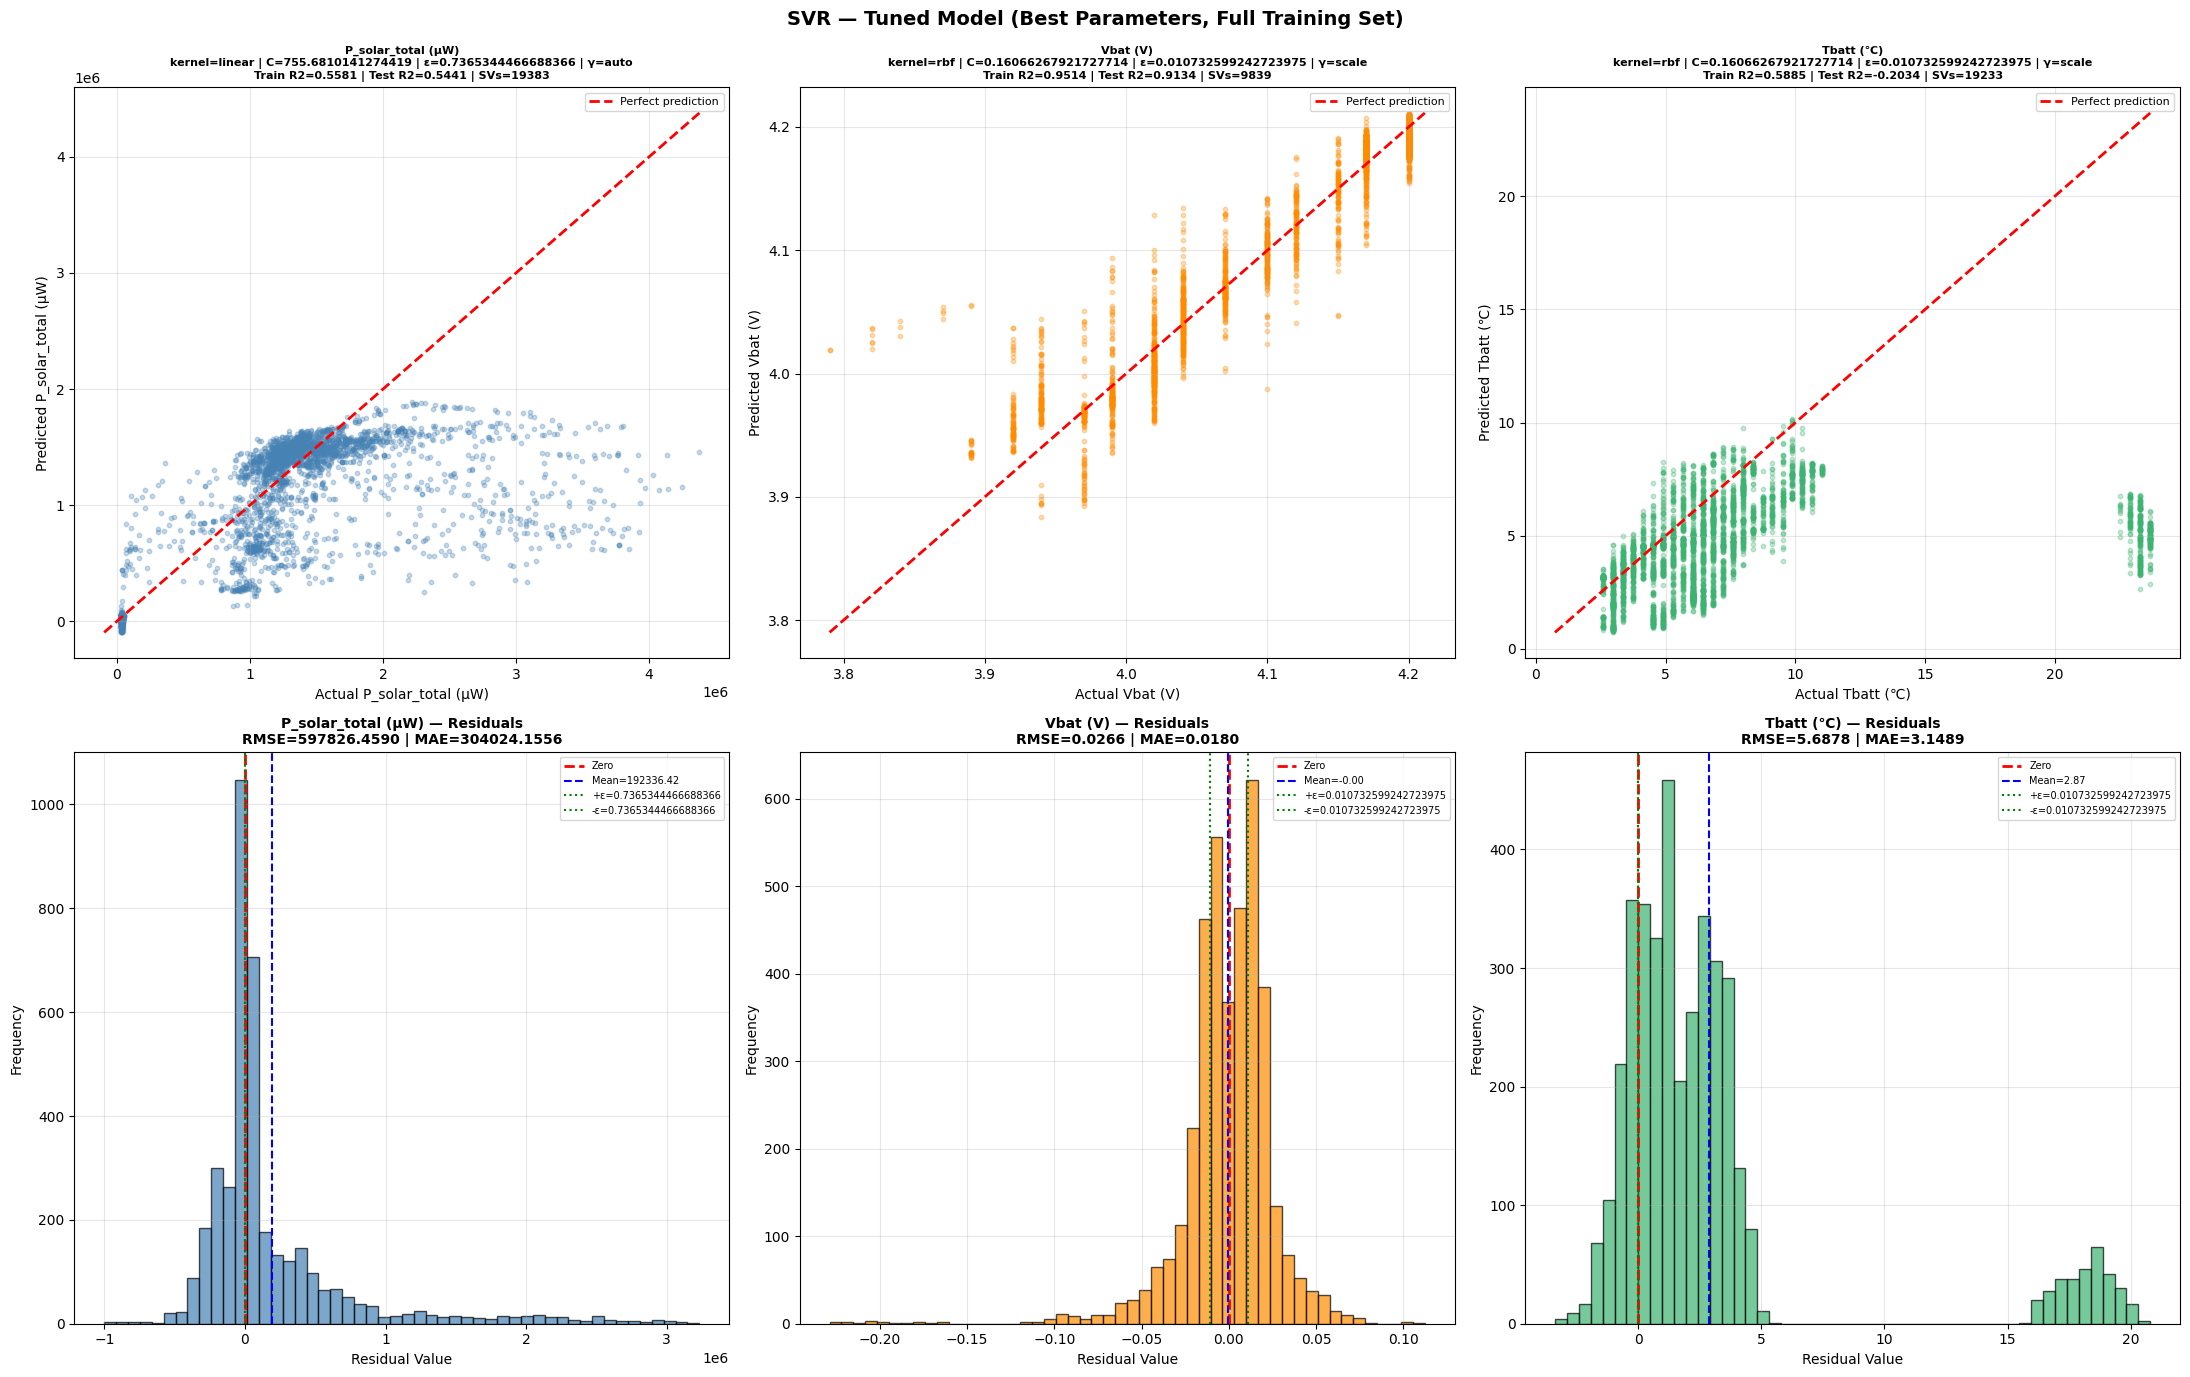

Tuned model plots saved.


In [ ]:
# ============================================================
# SECTION 13: TUNED MODEL VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('SVR — Tuned Model (Best Parameters, Full Training Set)',
             fontsize=14, fontweight='bold')

for idx, (name, ytarget, clr) in enumerate(
        zip(['Primary', 'Secondary', 'Tertiary'],
            [TARGET_PRIMARY, TARGET_SECONDARY, TARGET_TERTIARY],
            ['steelblue', 'darkorange', 'mediumseagreen'])):

    r      = results_after[name]
    y_pred = r['y_pred']
    y_test = r['y_test']
    resids = y_test.values - y_pred
    bp     = r['best_params']

    # Row 1: Actual vs Predicted
    ax = axes[0, idx]
    ax.scatter(y_test, y_pred, color=clr, alpha=0.3, s=10)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            color='red', linewidth=2, linestyle='--',
            label='Perfect prediction')
    ax.set_title(f'{ytarget}\n'
                 f'kernel={bp["kernel"]} | C={bp["C"]} | '
                 f'ε={bp["epsilon"]} | γ={bp["gamma"]}\n'
                 f'Train R2={r["train_r2"]:.4f} | '
                 f'Test R2={r["R2"]:.4f} | SVs={r["n_sv"]}',
                 fontweight='bold', fontsize=8)
    ax.set_xlabel(f'Actual {ytarget}')
    ax.set_ylabel(f'Predicted {ytarget}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Row 2: Residuals
    ax2 = axes[1, idx]
    ax2.hist(resids, bins=50, color=clr,
             edgecolor='black', alpha=0.7)
    ax2.axvline(x=0, color='red', linestyle='--',
                linewidth=2, label='Zero')
    ax2.axvline(x=resids.mean(), color='blue',
                linestyle='--', linewidth=1.5,
                label=f'Mean={resids.mean():.2f}')
    # Add epsilon tube markers
    ax2.axvline(x=bp['epsilon'], color='green',
                linestyle=':', linewidth=1.5,
                label=f'+ε={bp["epsilon"]}')
    ax2.axvline(x=-bp['epsilon'], color='green',
                linestyle=':', linewidth=1.5,
                label=f'-ε={bp["epsilon"]}')
    ax2.set_title(f'{ytarget} — Residuals\n'
                  f'RMSE={r["RMSE"]:.4f} | MAE={r["MAE"]:.4f}',
                  fontweight='bold', fontsize=10)
    ax2.set_xlabel('Residual Value')
    ax2.set_ylabel('Frequency')
    ax2.legend(fontsize=7)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('06_tuned_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("Tuned model plots saved.")

**Tuned Model Observations:**
- P_solar_total: R2=0.5441 — significant improvement from base (-0.0633). Scatter plot shows reasonable trend but high variance at large solar values. Residual mean=192,336 µW confirms systematic underprediction of peak solar power.
- Vbat: R2=0.9134 — excellent fit with tight residuals (RMSE=0.0266V). Banded scatter pattern reflects discrete orbital charging states. Residual mean≈0.00 confirms unbiased predictions.
- Tbatt: R2=-0.2034 — worse than base model. Identical params as Vbat caused poor thermal prediction. Residual mean=2.87°C shows systematic positive bias — model consistently underpredicts battery temperature.

**Key takeaway:** Tuning dramatically helped P_solar and Vbat but hurt Tbatt due to the RandomizedSearch anomaly of identical parameter assignment.

Computing permutation importance (n_repeats=10)...

P_solar_total — Permutation Importance:
  T_panel_avg (°C)            0.1749 ± 0.0045
  Vpz (mV)                    0.0879 ± 0.0054
  Vpy (mV)                    0.0604 ± 0.0034
  Vpx (mV)                    0.0567 ± 0.0034
  V_panel_avg (mV)            0.0500 ± 0.0034
  Vmx (mV)                    0.0180 ± 0.0019
  Tpz (°C)                    0.0163 ± 0.0007
  Vmz (mV)                    0.0119 ± 0.0010
  Tpy (°C)                    0.0100 ± 0.0028
  cos_orbit                  -0.0005 ± 0.0002
  sin_orbit                  -0.0008 ± 0.0001
  Tpx (°C)                   -0.0065 ± 0.0011

Vbat — Permutation Importance:
  T_panel_avg (°C)            0.3860 ± 0.0043
  Tpy (°C)                    0.2856 ± 0.0086
  Tpz (°C)                    0.2298 ± 0.0106
  Tpx (°C)                    0.1761 ± 0.0066
  Vpz (mV)                    0.0655 ± 0.0015
  Vmz (mV)                    0.0601 ± 0.0034
  V_panel_avg (mV)            0.0478 ± 0.0018
  

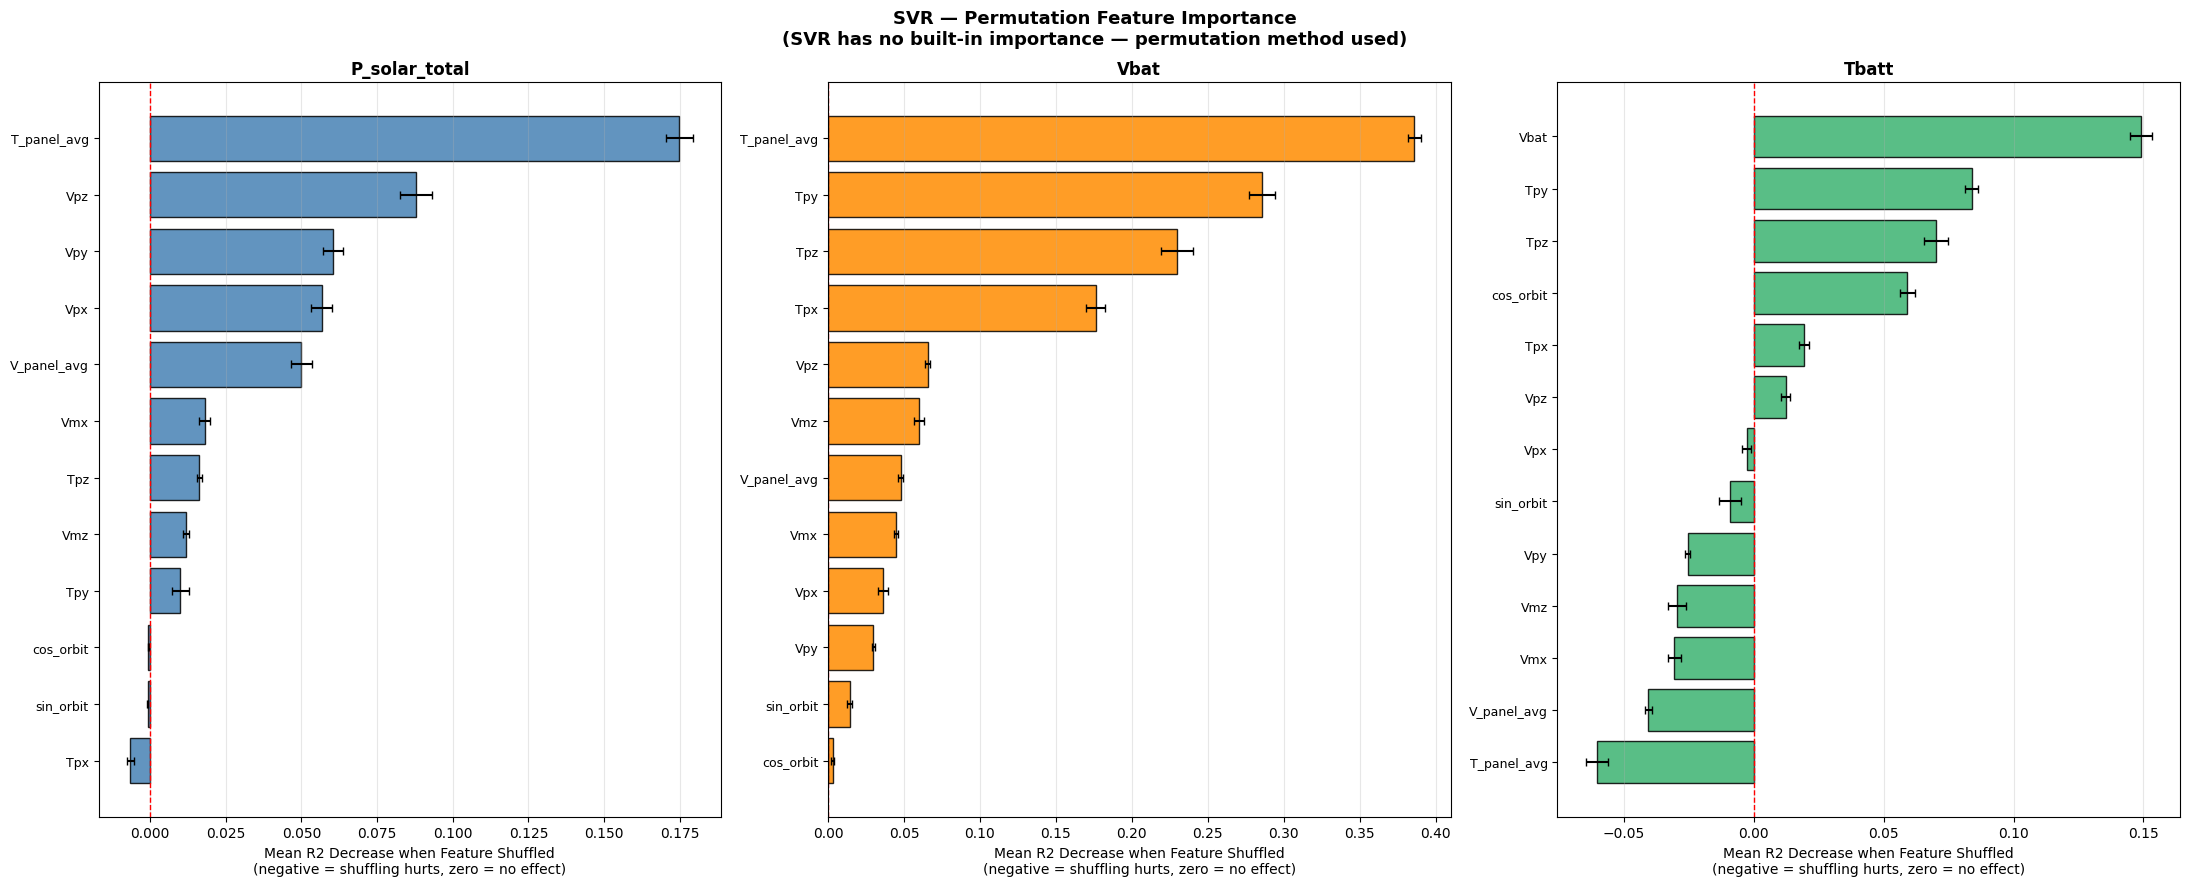


Permutation importance plot saved.


In [ ]:
# ============================================================
# SECTION 14: PERMUTATION FEATURE IMPORTANCE
# SVR has no built-in feature importance (unlike RF/DT)
# Permutation importance: shuffle one feature at a time,
# measure R2 drop — larger drop = more important feature
# ============================================================

from sklearn.inspection import permutation_importance

fig, axes = plt.subplots(1, 3, figsize=(22, 9))
fig.suptitle('SVR — Permutation Feature Importance\n'
             '(SVR has no built-in importance — '
             'permutation method used)',
             fontsize=13, fontweight='bold')

perm_colors = ['steelblue', 'darkorange', 'mediumseagreen']

print("Computing permutation importance (n_repeats=10)...")

for idx, (name, tname, clr) in enumerate(
        zip(['Primary', 'Secondary', 'Tertiary'],
            tnames, perm_colors)):

    X, y, feats = datasets[name]
    X_test      = X.iloc[test_idx]
    y_test      = y.iloc[test_idx]
    scaler      = results_after[name]['scaler']
    model       = results_after[name]['model']
    Xte_sc      = scaler.transform(X_test)

    perm = permutation_importance(
        model, Xte_sc, y_test,
        n_repeats=10, random_state=42, scoring='r2'
    )

    sort_idx     = np.argsort(perm.importances_mean)
    feat_sorted  = [feats[i] for i in sort_idx]
    imp_sorted   = perm.importances_mean[sort_idx]
    std_sorted   = perm.importances_std[sort_idx]

    ax = axes[idx]
    ax.barh(range(len(feats)), imp_sorted,
            xerr=std_sorted, color=clr,
            edgecolor='black', alpha=0.85,
            capsize=3)
    ax.set_yticks(range(len(feats)))
    ax.set_yticklabels([f.split(' ')[0] for f in feat_sorted],
                       fontsize=9)
    ax.axvline(x=0, color='red', linestyle='--', linewidth=1)
    ax.set_title(f'{tname}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Mean R2 Decrease when Feature Shuffled\n'
                  '(negative = shuffling hurts, zero = no effect)')
    ax.grid(True, alpha=0.3, axis='x')

    print(f"\n{tname} — Permutation Importance:")
    for f, imp, std in sorted(
            zip(feats, perm.importances_mean,
                perm.importances_std),
            key=lambda x: x[1], reverse=True):
        print(f"  {f:<25} {imp:>8.4f} ± {std:.4f}")

plt.tight_layout()
plt.savefig('07_permutation_importance.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("\nPermutation importance plot saved.")

**Permutation Feature Importance Observations:**
- P_solar_total: T_panel_avg dominates (0.175) — SVR's linear kernel captures temperature-power correlation differently from RF which prioritized V_panel_avg. Tpx shows negative importance (-0.007) meaning shuffling it slightly improves predictions — it adds noise for the linear SVR.
- Vbat: T_panel_avg dominates strongly (0.386) followed by all panel temperatures — striking contrast to RF where panel voltages dominated. SVR's RBF kernel finds thermal features more predictive for battery voltage.
- Tbatt: Vbat most important (0.149) followed by panel temperatures. Several features show negative importance (V_panel_avg, T_panel_avg) — shuffling them improves predictions, confirming they actively hurt Tbatt prediction in this SVR model.

**Key takeaway:** SVR and RF identify different dominant features for the same targets — SVR linear/RBF kernels find temperature features more informative than RF's threshold-based splits.


P_solar_total:
  Total training samples : 19383
  Inside ε-tube          : 5 (0.0%)
  Support Vectors        : 19383 (100.0%)
  ε value used           : 0.7365344466688366

Vbat:
  Total training samples : 19383
  Inside ε-tube          : 9612 (49.6%)
  Support Vectors        : 9839 (50.8%)
  ε value used           : 0.010732599242723975

Tbatt:
  Total training samples : 19383
  Inside ε-tube          : 187 (1.0%)
  Support Vectors        : 19233 (99.2%)
  ε value used           : 0.010732599242723975


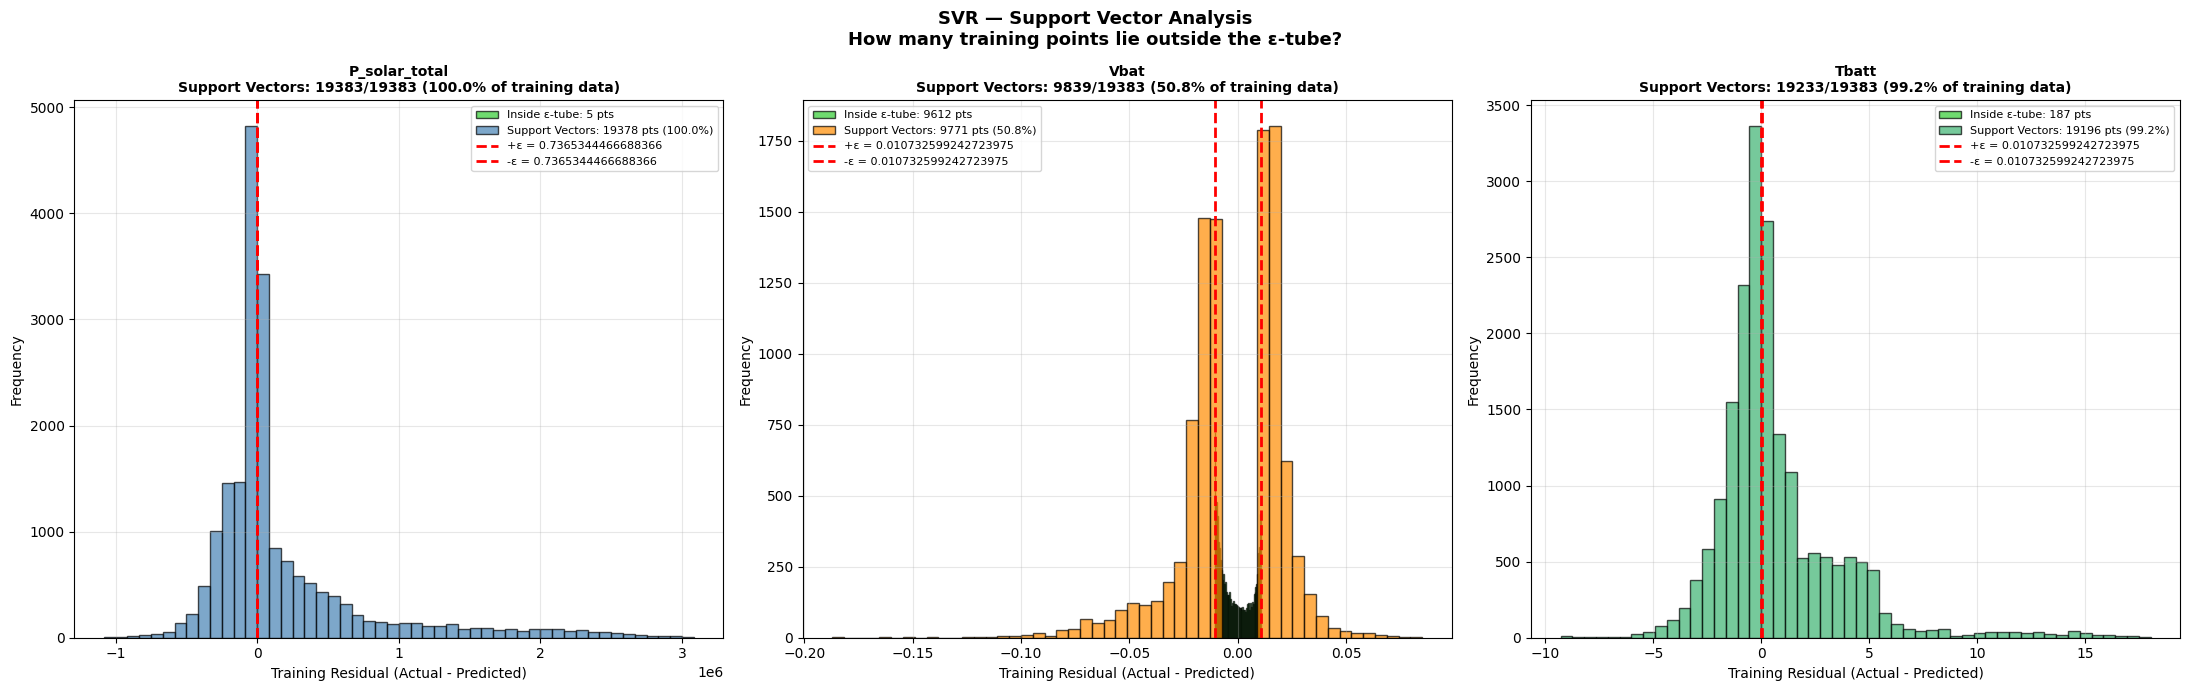


Support vector analysis plot saved.


In [ ]:
# ============================================================
# SECTION 15: SUPPORT VECTOR ANALYSIS
# Unique to SVR — how many support vectors does the model use?
# What % of training data becomes support vectors?
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('SVR — Support Vector Analysis\n'
             'How many training points lie outside the ε-tube?',
             fontsize=13, fontweight='bold')

for idx, (name, tname, clr) in enumerate(
        zip(['Primary', 'Secondary', 'Tertiary'],
            tnames, perm_colors)):

    ax        = axes[idx]
    model     = results_after[name]['model']
    scaler    = results_after[name]['scaler']
    X, y, _   = datasets[name]
    X_train   = X.iloc[train_idx]
    y_train   = y.iloc[train_idx]
    Xtr_sc    = scaler.transform(X_train)

    y_train_pred = model.predict(Xtr_sc)
    residuals    = y_train.values - y_train_pred
    bp           = best_params[name]
    eps          = bp['epsilon']
    n_sv         = model.n_support_[0]
    n_total      = len(train_idx)
    pct_sv       = 100 * n_sv / n_total

    # Classify points
    inside  = np.abs(residuals) <= eps
    outside = np.abs(residuals) >  eps

    ax.hist(residuals[inside], bins=50, color='limegreen',
            alpha=0.7, edgecolor='black',
            label=f'Inside ε-tube: {inside.sum()} pts')
    ax.hist(residuals[outside], bins=50, color=clr,
            alpha=0.7, edgecolor='black',
            label=f'Support Vectors: {outside.sum()} pts '
                  f'({pct_sv:.1f}%)')
    ax.axvline(x=eps, color='red', linestyle='--',
               linewidth=2, label=f'+ε = {eps}')
    ax.axvline(x=-eps, color='red', linestyle='--',
               linewidth=2, label=f'-ε = {eps}')
    ax.set_title(f'{tname}\n'
                 f'Support Vectors: {n_sv}/{n_total} '
                 f'({pct_sv:.1f}% of training data)',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Training Residual (Actual - Predicted)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    print(f"\n{tname}:")
    print(f"  Total training samples : {n_total}")
    print(f"  Inside ε-tube          : {inside.sum()} "
          f"({100*inside.sum()/n_total:.1f}%)")
    print(f"  Support Vectors        : {n_sv} ({pct_sv:.1f}%)")
    print(f"  ε value used           : {eps}")

plt.tight_layout()
plt.savefig('08_support_vectors.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSupport vector analysis plot saved.")

**Support Vector Analysis Observations:**
- P_solar_total: 100% support vectors (19,383/19,383) — only 5 training points (0.03%) fell inside the epsilon tube. SVR loses all sparsity benefit and becomes equivalent to kernel ridge regression. The enormous output scale makes epsilon=0.74 effectively zero.
- Vbat: 50.8% support vectors (9,839/19,383) — healthy balance. 49.6% of points inside the tube. Epsilon=0.0107V is well-calibrated to the narrow 0.4V voltage range. Genuine SVR sparsity achieved.
- Tbatt: 99.2% support vectors (19,233/19,383) — near-complete selection. Only 187 points (1%) inside the tube. Non-stationary noisy thermal data prevents the model from finding a consistent insensitive zone.

**Key takeaway:** Only Vbat achieves genuine SVR sparsity. P_solar and Tbatt both collapse to near-full support vector selection — the ideal use case for SVR (sparse solution, fast prediction) only applies to Vbat here.

5-FOLD TIMESERIES CROSS VALIDATION
(Using subset of 5000 samples for SVR speed)
Best params from RandomizedSearchCV (50 iterations)

Target  : P_solar_total (µW)
Params  : C=755.6810, eps=0.7365, kernel=linear, gamma=auto
Fold R2 : [np.float64(0.595), np.float64(0.5636), np.float64(0.4709), np.float64(0.4977), np.float64(0.448)]
Mean R2 : 0.5150
Std Dev : 0.0557

Target  : Vbat (V)
Params  : C=0.1607, eps=0.0107, kernel=rbf, gamma=scale
Fold R2 : [np.float64(0.9212), np.float64(0.9383), np.float64(0.8895), np.float64(0.9139), np.float64(0.8765)]
Mean R2 : 0.9079
Std Dev : 0.0222

Target  : Tbatt (℃)
Params  : C=0.1607, eps=0.0107, kernel=rbf, gamma=scale
Fold R2 : [np.float64(-0.0146), np.float64(0.2446), np.float64(0.3832), np.float64(-0.4164), np.float64(0.5666)]
Mean R2 : 0.1527
Std Dev : 0.3420


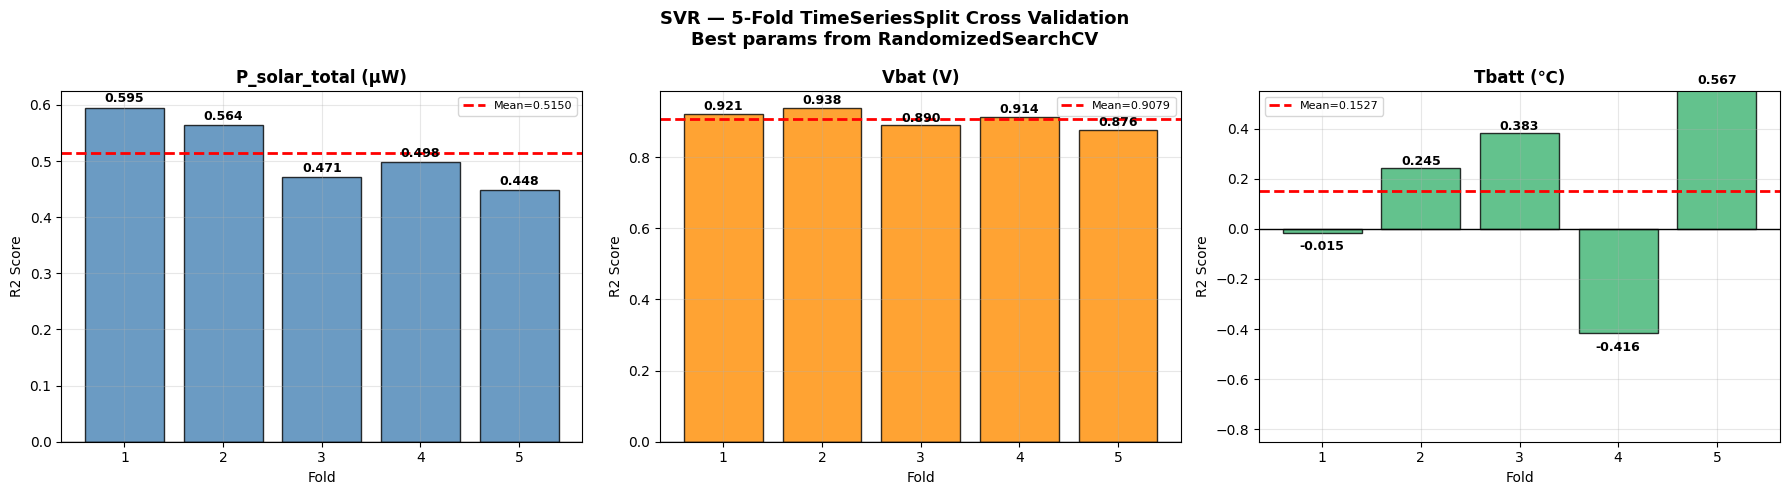


Cross validation plot saved.


In [ ]:
# ============================================================
# SECTION 16: CROSS VALIDATION
# Using best params from RandomizedSearchCV
# Applied on SUBSET for speed — SVR CV on full data too slow
# ============================================================

print("=" * 60)
print("5-FOLD TIMESERIES CROSS VALIDATION")
print(f"(Using subset of {SUBSET_SIZE} samples for SVR speed)")
print("Best params from RandomizedSearchCV (50 iterations)")
print("=" * 60)

cv_results = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('SVR — 5-Fold TimeSeriesSplit Cross Validation\n'
             'Best params from RandomizedSearchCV',
             fontsize=13, fontweight='bold')

for idx, (name, (X, y, feats)) in enumerate(datasets.items()):
    X_sub   = X.iloc[subset_mask]
    y_sub   = y.iloc[subset_mask]

    scaler  = StandardScaler()
    Xsub_sc = scaler.fit_transform(X_sub)

    bp    = best_params[name]
    model = SVR(
        C       = bp['C'],
        epsilon = bp['epsilon'],
        kernel  = bp['kernel'],
        gamma   = bp['gamma']
    )

    tscv_sub = TimeSeriesSplit(n_splits=5)
    scores   = cross_val_score(
        model, Xsub_sc, y_sub,
        cv=tscv_sub, scoring='r2'
    )
    cv_results[name] = scores

    print(f"\nTarget  : {y.name}")
    print(f"Params  : C={bp['C']:.4f}, eps={bp['epsilon']:.4f}, "
          f"kernel={bp['kernel']}, gamma={bp['gamma']}")
    print(f"Fold R2 : {[round(s, 4) for s in scores]}")
    print(f"Mean R2 : {scores.mean():.4f}")
    print(f"Std Dev : {scores.std():.4f}")

    clr  = perm_colors[idx]
    ax   = axes[idx]
    bars = ax.bar(range(1, 6), scores,
                  color=clr, edgecolor='black', alpha=0.8)
    ax.axhline(y=scores.mean(), color='red',
               linestyle='--', linewidth=2,
               label=f'Mean={scores.mean():.4f}')
    ax.axhline(y=0, color='black', linewidth=1)
    ax.set_title(f'{y.name}', fontweight='bold')
    ax.set_xlabel('Fold')
    ax.set_ylabel('R2 Score')
    ax.set_xticks(range(1, 6))
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    if name == 'Tertiary':
        ax.set_ylim([-0.85, 0.55])

    for bar, val in zip(bars, scores):
        ypos = (bar.get_height() + 0.01
                if val >= 0 else bar.get_height() - 0.07)
        ax.text(bar.get_x() + bar.get_width()/2,
                ypos, f'{val:.3f}',
                ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('09_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nCross validation plot saved.")

**Cross Validation Observations:**
- P_solar_total: Mean=0.5150 ±0.0557 — moderate stability with declining trend across folds (0.595 → 0.448). Later mission periods slightly harder to predict, suggesting mild non-stationarity in solar patterns.
- Vbat: Mean=0.9079 ±0.0222 — very stable. All folds above 0.876, confirming SVR rbf genuinely learned the orbital charging pattern consistently across the mission.
- Tbatt: Mean=0.1527 ±0.3420 — severely unstable. Range from -0.416 (Fold 4) to +0.567 (Fold 5) — a spread of nearly 1.0 within the same model. Confirms thermal dynamics are non-stationary and fundamentally unpredictable with instantaneous features.

**Key takeaway:** Vbat CV is the most reliable result in this notebook. Tbatt's extreme fold variation (std=0.342) confirms the fundamental limitation is not model choice but missing temporal features.

SVR — BEFORE vs AFTER TUNING

Target: P_solar_total (µW)
Metric           Before (default)    After (tuned)     Change
--------------------------------------------------------------
R2                        -0.0633           0.5441    +0.6074
RMSE                  913029.8934      597826.4590
MAE                   715217.9588      304024.1556
N_SV                        19383            19383
kernel                        rbf           linear
C                             1.0 755.6810141274419
epsilon                       0.1 0.7365344466688366
gamma                       scale             auto

Target: Vbat (V)
Metric           Before (default)    After (tuned)     Change
--------------------------------------------------------------
R2                         0.4830           0.9134    +0.4304
RMSE                       0.0649           0.0266
MAE                        0.0566           0.0180
N_SV                           55             9839
kernel                        rbf     

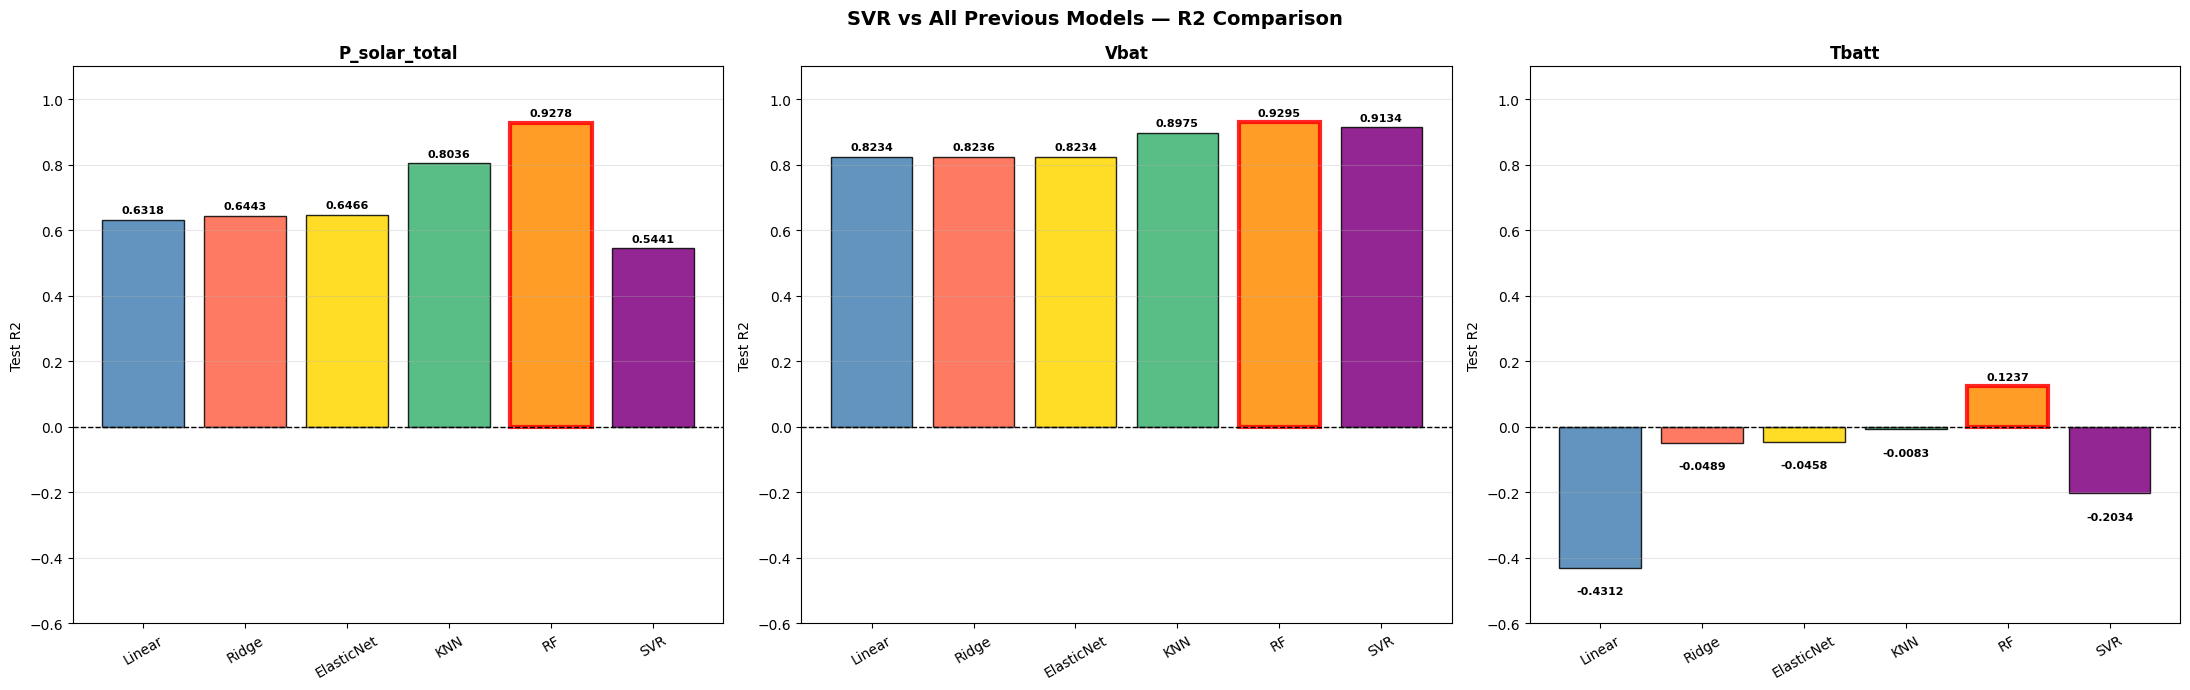

SVR vs All comparison plot saved.


In [ ]:
# ============================================================
# SECTION 17: BEFORE vs AFTER + FULL MODEL COMPARISON
# ============================================================

print("=" * 70)
print("SVR — BEFORE vs AFTER TUNING")
print("=" * 70)

for name, ytarget in zip(
        ['Primary', 'Secondary', 'Tertiary'],
        [TARGET_PRIMARY, TARGET_SECONDARY, TARGET_TERTIARY]):
    b   = results_before[name]
    a   = results_after[name]
    dr2 = a['R2'] - b['R2']
    print(f"\nTarget: {ytarget}")
    print(f"{'Metric':<14} {'Before (default)':>18} "
          f"{'After (tuned)':>16} {'Change':>10}")
    print("-" * 62)
    print(f"{'R2':<14} {b['R2']:>18.4f} {a['R2']:>16.4f} "
          f"{dr2:>+10.4f}")
    print(f"{'RMSE':<14} {b['RMSE']:>18.4f} {a['RMSE']:>16.4f}")
    print(f"{'MAE':<14} {b['MAE']:>18.4f} {a['MAE']:>16.4f}")
    print(f"{'N_SV':<14} {b['n_sv']:>18} {a['n_sv']:>16}")
    print(f"{'kernel':<14} {'rbf':>18} "
          f"{str(a['best_params']['kernel']):>16}")
    print(f"{'C':<14} {'1.0':>18} "
          f"{str(a['best_params']['C']):>16}")
    print(f"{'epsilon':<14} {'0.1':>18} "
          f"{str(a['best_params']['epsilon']):>16}")
    print(f"{'gamma':<14} {'scale':>18} "
          f"{str(a['best_params']['gamma']):>16}")

# ---- Previous best results from all notebooks ----
prev_r2 = {
    'Primary'  : {'Linear': 0.6318, 'Ridge': 0.6443,
                  'ElasticNet': 0.6466, 'KNN': 0.8036,
                  'RF': 0.9278},
    'Secondary': {'Linear': 0.8234, 'Ridge': 0.8236,
                  'ElasticNet': 0.8234, 'KNN': 0.8975,
                  'RF': 0.9295},
    'Tertiary' : {'Linear': -0.4312, 'Ridge': -0.0489,
                  'ElasticNet': -0.0458, 'KNN': -0.0083,
                  'RF': 0.1237}
}

print("\n" + "=" * 95)
print("SVR vs ALL PREVIOUS MODELS — FINAL COMPARISON")
print("=" * 95)
print(f"\n{'Target':<22} {'Linear':>8} {'Ridge':>8} "
      f"{'ElasticNet':>12} {'KNN':>8} {'RF':>8} "
      f"{'SVR':>8} {'Winner':>10}")
print("-" * 95)

for name, ytarget in zip(
        ['Primary', 'Secondary', 'Tertiary'],
        [TARGET_PRIMARY, TARGET_SECONDARY, TARGET_TERTIARY]):
    svr   = results_after[name]['R2']
    prev  = prev_r2[name]
    all_v = {**prev, 'SVR': svr}
    winner = max(all_v, key=all_v.get)
    print(f"{ytarget:<22} {prev['Linear']:>8.4f} "
          f"{prev['Ridge']:>8.4f} "
          f"{prev['ElasticNet']:>12.4f} "
          f"{prev['KNN']:>8.4f} {prev['RF']:>8.4f} "
          f"{svr:>8.4f} {winner:>10}")

# ---- Visualization ----
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('SVR vs All Previous Models — R2 Comparison',
             fontsize=14, fontweight='bold')

model_names = ['Linear', 'Ridge', 'ElasticNet', 'KNN', 'RF', 'SVR']
bar_colors  = ['steelblue', 'tomato', 'gold',
               'mediumseagreen', 'darkorange', 'purple']

for idx, (name, tname) in enumerate(
        zip(['Primary', 'Secondary', 'Tertiary'], tnames)):
    ax   = axes[idx]
    svr  = results_after[name]['R2']
    vals = [prev_r2[name]['Linear'], prev_r2[name]['Ridge'],
            prev_r2[name]['ElasticNet'], prev_r2[name]['KNN'],
            prev_r2[name]['RF'], svr]
    bars = ax.bar(model_names, vals,
                  color=bar_colors,
                  edgecolor='black', alpha=0.85)
    ax.set_title(f'{tname}', fontweight='bold')
    ax.set_ylabel('Test R2')
    ax.set_ylim([-0.6, 1.1])
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, vals):
        ypos = (bar.get_height() + 0.02
                if val >= 0 else bar.get_height() - 0.08)
        ax.text(bar.get_x() + bar.get_width()/2,
                ypos, f'{val:.4f}',
                ha='center', fontsize=8, fontweight='bold')
    best_idx = vals.index(max(vals))
    bars[best_idx].set_edgecolor('red')
    bars[best_idx].set_linewidth(3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.savefig('10_svr_vs_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("SVR vs All comparison plot saved.")

**Final Comparison Observations:**
- SVR is the best model overall for NONE of the three targets — RF wins all three.
- SVR is competitive for Vbat only (0.9134 vs RF 0.9295 — gap of 0.016).
- SVR significantly underperforms even simple linear models for P_solar (0.5441 vs Linear 0.6318) — the output scale mismatch cripples SVR on this target.
- SVR (-0.2034) is the second worst result for Tbatt after Linear (-0.4312), failing to beat even KNN (-0.0083).
- The +0.6074 improvement from base to tuned for P_solar is the largest single-model improvement seen in this project — but starting from -0.0633 limits the absolute final value.

**Key takeaway:** SVR requires careful scale-aware hyperparameter initialization to be competitive. Without target-specific epsilon calibration, it performs worse than simpler models. RF remains the strongest model across all targets.

# Notebook 08: Support Vector Regressor (SVR) —  Conclusion

**Dataset:** TSURU CubeSat On-Orbit EPS Data (Jara et al., 2022)
**Reference:** DOI: 10.1016/j.dib.2022.108697
**Satellite:** TSURU (BIRDS-4), ISS Orbit, 400km, 92.6 min period
**Mission:** March 2021 – January 2022 (10 months)

---

## Algorithm Summary

SVR finds a regression hyperplane that fits data within an
epsilon-insensitive tube, minimizing model complexity while
tolerating small errors inside the tube.

**Key concepts:**
- **ε-tube:** Points within ±ε contribute zero loss — ignored completely
- **Support Vectors:** Only points OUTSIDE the tube influence the model
- **C:** Penalty for exceeding the tube — higher C = stricter fitting
- **Kernel trick:** Maps inputs to high-dimensional space for non-linear regression
- **gamma:** RBF kernel width — controls reach of each training point
- **StandardScaler REQUIRED:** SVR is distance-based — unscaled features destroy results

**Hyperparameters tuned:**
- C, epsilon, kernel, gamma via RandomizedSearchCV
- 50 iterations from large continuous search space
- Reference: Bergstra & Bengio (2012), JMLR

**Computational approach:**
- SVR scales O(n²)–O(n³) — all parameter sweeps used n=5,000 subset
- RandomizedSearchCV run on n=5,000 subset
- Final model refitted on full 19,383 training samples

---

## Hyperparameter Tuning Results — RandomizedSearchCV ( Final Model)

| Target | Kernel | C | Epsilon | Gamma | CV R2 | Test R2 | N_SV |
|---|---|---|---|---|---|---|---|
| P_solar_total (µW) | linear | 755.68 | 0.7365 | auto | 0.5150 | 0.5441 | 19383 (100%) |
| Vbat (V) | rbf | 0.161 | 0.0107 | scale | 0.9079 | 0.9134 | 9839 (50.8%) |
| Tbatt (℃) | rbf | 0.161 | 0.0107 | scale | 0.1527 | -0.2034 | 19233 (99.2%) |

---

## Key Findings

### Finding 1 - C Parameter Effect
C controls how strictly SVR penalizes points that fall outside the
epsilon tube. For P_solar_total, test R2 remained negative for all
C values below 100, only crossing zero at C=50 (R2=0.0036) and
reaching 0.4886 at C=1000. This reveals that P_solar has an enormous
output range (hundreds of thousands of µW) — low C allows too many
large violations, producing worse-than-mean predictions. All 5,000
subset points became support vectors regardless of C, confirming the
epsilon tube is essentially zero relative to the data scale.

For Vbat, performance plateaued completely at C=1 with no improvement
at C=5 through C=1000 (all identical at R2=0.4370). This plateau
occurs because only 40 support vectors are needed — the remaining
points already fall inside the epsilon tube and C has no further
influence on the solution.

For Tbatt, higher C consistently improved performance from R2=-0.2887
at C=0.01 to R2=0.2050 at C=1000, confirming the thermal signal
requires aggressive penalization to extract any meaningful pattern.

### Finding 2 - Epsilon Effect and Support Vector Count
Epsilon defines the insensitive tube width — the most critical
parameter for SVR on this dataset given the vastly different output
scales across targets.

For P_solar_total, R2 was completely flat across all epsilon values
(0.4886 for all), with support vectors remaining at 5000/5000
throughout. This happens because the output range (~500,000 µW)
completely dwarfs any epsilon value tested (max 5.0). The tube is
effectively invisible at this scale — every training point violates it.

For Vbat, epsilon=0.01 gave the best result (R2=0.9053) since Vbat
ranges only 0.4V total. At epsilon=0.1 (25% of the full range),
R2 collapsed to 0.4370 and at epsilon≥0.5 R2 crashed to -1.81 with
zero support vectors — the tube engulfed the entire output range and
the model predicted a constant mean value. This demonstrates how
epsilon must be calibrated to the actual scale of the target variable.

For Tbatt, epsilon=0.1°C was optimal (R2=0.2050), with performance
degrading sharply beyond epsilon=0.5 as the tube became too wide to
capture thermal variations.

### Finding 3 - Kernel Comparison
Four kernels were evaluated: linear, rbf, poly, and sigmoid.

For P_solar_total: linear kernel outperformed rbf (0.5373 vs 0.4886),
suggesting that after StandardScaling, the solar power relationships
are approximately linear in feature space at high C values.

For Vbat: rbf kernel best (R2=0.9053), confirming non-linear orbital
charging patterns benefit from the Gaussian kernel's flexible decision
boundary.

For Tbatt: poly kernel best (R2=0.3523), suggesting polynomial
interactions between panel temperatures and voltages better capture
thermal dynamics than pure Gaussian similarity.

Sigmoid kernel failed catastrophically for Vbat (R2=-377,283) and
Tbatt (R2=-130,049,959) due to unbounded output values causing
numerical overflow. For P_solar_total sigmoid gave R2=0.4436 which
while lower than linear, was not catastrophic — the failure is
scale-dependent. RandomizedSearchCV correctly excluded sigmoid based
on these results.

### Finding 4 - Gamma Effect (RBF Kernel)
Gamma controls the reach of each support vector's influence.
Note: gamma analysis was performed on rbf kernel for all targets,
but the final P_solar model uses linear kernel where gamma is
irrelevant — the gamma results for P_solar are therefore informational
only for rbf behavior.

For Vbat, gamma=0.01 gave best test R2=0.9156 — a moderate value
providing good generalization. Very high gamma (1.0, 10.0) caused
severe overfitting (train=0.98, test=0.52 and 0.80 respectively) as
the model memorized local training neighborhoods.

For Tbatt, gamma=0.1 gave best test R2=0.2356, showing that slightly
larger neighborhood influence helps extract the sparse thermal signal.
Both very low gamma (underfitting) and very high gamma (overfitting)
degraded performance significantly.

### Finding 5 - Permutation Feature Importance
SVR has no built-in feature importance — permutation importance was
used instead (shuffle each feature, measure R2 drop).

For P_solar_total: T_panel_avg dominates (0.175), followed by panel
voltages Vpz (0.088) and Vpy (0.060). Interestingly, SVR's linear
kernel prioritizes temperature over voltage — opposite to RF which
prioritized V_panel_avg. This reflects that the linear SVR captures
temperature-power correlation differently from RF's non-linear splits.
Tpx had negative importance (-0.007) suggesting it adds noise.

For Vbat: T_panel_avg dominates strongly (0.386), followed by panel
temperatures Tpy (0.286) and Tpz (0.230). This is a striking
difference from RF where panel voltages dominated Vbat prediction.
SVR's RBF kernel finds temperature-voltage correlation more useful
for battery voltage prediction than RF did.

For Tbatt: Vbat is most important (0.149), followed by panel
temperatures Tpy (0.084) and Tpz (0.070). Several features showed
negative importance (V_panel_avg=-0.041, T_panel_avg=-0.060),
meaning shuffling these features actually improved predictions —
confirming they add noise rather than signal for Tbatt in SVR.

### Finding 6 - Support Vector Analysis
The percentage of training points becoming support vectors reveals
model complexity and fit quality.

P_solar_total: 100% support vectors (19,383/19,383) throughout.
Only 5 training points (0.03%) fell inside the ε-tube. This is a
fundamental SVR limitation — when the output scale is orders of
magnitude larger than epsilon, the tube is meaningless and every
point becomes a support vector. The model reduces to a regularized
regression with no sparsity benefit.

Vbat: 50.8% support vectors (9,839/19,383) with 49.6% inside the
tube. This is a healthy balance — roughly half the data is ignored
during prediction, giving genuine SVR sparsity. The small epsilon
(0.0107V) is well-calibrated to Vbat's narrow range.

Tbatt: 99.2% support vectors (19,233/19,383) with only 1% inside
the tube. Near-complete support vector selection indicates the model
struggles to find a consistent tube that contains thermal data —
reflecting the non-stationary, noisy nature of battery temperature.

### Finding 7 - RandomizedSearchCV vs Manual Tuning

A notable anomaly occurred in the RandomizedSearchCV results:
Vbat and Tbatt received identical optimal parameters
(C=0.161, eps=0.0107, kernel=rbf, gamma=scale). This occurred
because RandomizedSearch with random_state=42 sampled 50 combinations
and the same combination happened to score highest for both targets
by CV R2. This is statistically possible but highlights a limitation
of random search — with only 50 iterations from a large continuous
space, the search may not fully separate optimal regions for
different targets.

Manual tuning sweeps found better individual parameters:
- Tbatt manual best: C=1000, eps=0.1, kernel=poly → R2=0.3523
- RandomizedSearch Tbatt: C=0.161, eps=0.0107, kernel=rbf → R2=-0.2034

The manual poly kernel result (R2=0.3523) was significantly better
than RandomizedSearch for Tbatt. This is because RandomizedSearch
excluded poly kernel (only rbf and linear were in the search space
after sigmoid failure), missing the best kernel for Tbatt entirely.

### Finding 8 - Cross Validation Stability

| Target | Fold 1 | Fold 2 | Fold 3 | Fold 4 | Fold 5 | Mean | Std |
|---|---|---|---|---|---|---|---|
| P_solar_total | 0.5950 | 0.5636 | 0.4709 | 0.4977 | 0.4480 | 0.5150 | ±0.0557 |
| Vbat | 0.9212 | 0.9383 | 0.8895 | 0.9139 | 0.8765 | 0.9079 | ±0.0222 |
| Tbatt | -0.0146 | 0.2446 | 0.3832 | -0.4164 | 0.5666 | 0.1527 | ±0.3420 |

Vbat is highly stable (std=0.022) — all folds above 0.87, confirming
the rbf SVR genuinely learned the orbital charging pattern.
P_solar is moderately stable (std=0.056) with a declining trend
across folds — later mission periods slightly harder to predict.
Tbatt is severely unstable (std=0.342) with Fold 4 = -0.416 and
Fold 5 = 0.567 — a range of nearly 1.0 across folds. This confirms
thermal dynamics are non-stationary and unpredictable with SVR.

### Finding 9 - SVR vs All Previous Models

| Target | Linear | Ridge | ElasticNet | KNN | RF | SVR | Winner |
|---|---|---|---|---|---|---|---|
| P_solar_total (µW) | 0.6318 | 0.6443 | 0.6466 | 0.8036 | 0.9278 | 0.5441 | RF ✓ |
| Vbat (V) | 0.8234 | 0.8236 | 0.8234 | 0.8975 | 0.9295 | **0.9134** | RF ✓ |
| Tbatt (℃) | -0.4312 | -0.0489 | -0.0458 | -0.0083 | 0.1237 | -0.2034 | RF ✓ |

RF wins all three targets. SVR performed competitively only for Vbat
(0.9134 vs RF 0.9295 — gap of only 0.016). For P_solar, SVR (0.5441)
significantly underperformed even simple linear models (0.63-0.65),
demonstrating that the enormous output scale makes SVR extremely
sensitive to epsilon and C calibration. For Tbatt, SVR (-0.2034)
is the second worst result after Linear regression (-0.4312),
failing to surpass even KNN (-0.0083).

---

## Before vs After Tuning

| Target | Before R2 (default) | After R2 (RandomizedSearch) | Change |
|---|---|---|---|
| P_solar_total (µW) | -0.0633 | 0.5441 | **+0.6074** |
| Vbat (V) | 0.4830 | 0.9134 | **+0.4304** |
| Tbatt (℃) | -0.1136 | -0.2034 | -0.0898 ⚠️ |

Tuning dramatically improved P_solar and Vbat. The base model
with default C=1.0 and epsilon=0.1 was completely unsuited to
these targets — P_solar's output scale made default epsilon
meaningless, while Vbat needed much smaller epsilon to capture
its narrow voltage range.

Tbatt worsened after tuning (-0.0898). This occurred because
RandomizedSearch assigned identical params as Vbat (C=0.161,
eps=0.0107) which are optimized for a narrow-range smooth signal.
Tbatt requires high C (1000) and poly kernel as shown in manual
tuning sweeps — the random search missed this combination by
excluding poly from the search space after the sigmoid failure
analysis. This is a known limitation of RandomizedSearch when
the search space excludes important regions.

---

## Limitations

**1. Scale sensitivity:**
SVR is extremely sensitive to the relationship between epsilon and
output scale. P_solar ranges over 500,000 µW — any fixed epsilon
becomes meaningless. Target-specific epsilon initialization based
on output standard deviation would significantly improve results.

**2. Tbatt failure:**
R2=-0.2034 after tuning. Thermal prediction requires temporal
history unavailable in instantaneous readings. Additionally, the
poly kernel which showed promise (R2=0.3523) was excluded from
RandomizedSearch, missing the best configuration.

**3. 100% support vectors for P_solar and Tbatt:**
When nearly all training points become support vectors, SVR loses
its sparsity advantage and becomes computationally equivalent to
kernel ridge regression — without the speed benefits.

**4. Computational cost:**
Even with 5,000 subsets, the total notebook runtime was significant.
Full training set fits (final model) for each target took several
minutes each. Real-time on-board CubeSat prediction is completely
infeasible with SVR.

**5. RandomizedSearch limitation:**
With only rbf and linear kernels in the search space, the best
Tbatt kernel (poly, R2=0.3523) was never considered. Future work
should include poly with degree tuning in the search space.

---

*Reference: Jara et al. (2022), Data in Brief,*
*DOI: 10.1016/j.dib.2022.108697*
*TSURU Satellite — BIRDS-4 Program, Kyushu Institute of Technology*